In [1]:
%load_ext kedro.ipython

The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython


In [2]:
!uv pip install --upgrade seaborn matplotlib

Using Python 3.12.7 environment at: C:\Users\arczi\source\repos\Mini\Msi\wsi-reg-cls\wsi-reg\.venv
Resolved 14 packages in 576ms
Audited 14 packages in 2ms


In [3]:
import pandas as pd
pd.set_option('display.max_columns', None)
df = catalog.load("domy_fill_missing_values")
df = df.sort_index(axis=1)

[03/22/26 22:54:42] INFO     Loading data from domy_fill_missing_values (CSVDataset)...        ]8;id=641707;file://C:\Users\arczi\source\repos\Mini\Msi\wsi-reg-cls\wsi-reg\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=377745;file://C:\Users\arczi\source\repos\Mini\Msi\wsi-reg-cls\wsi-reg\.venv\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

In [4]:
cat_features_s = []
cat_features_b = []
num_features = []

for col in df.columns:
    if (df[col].dtype in ['object', 'string'] and df[col].nunique() < 10):
        cat_features_s.append(col)
    elif df[col].dtype in ['object', 'string'] and df[col].nunique() >= 10:
        cat_features_b.append(col)
    else:
        num_features.append(col)

df_cat_s = df[cat_features_s]
df_cat_b = df[cat_features_b]
df_num = df[num_features]


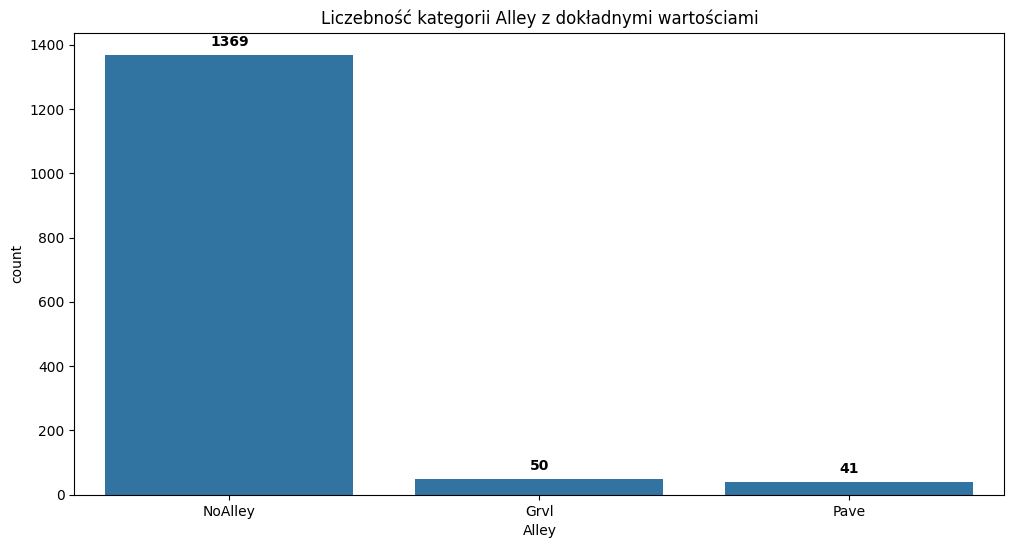

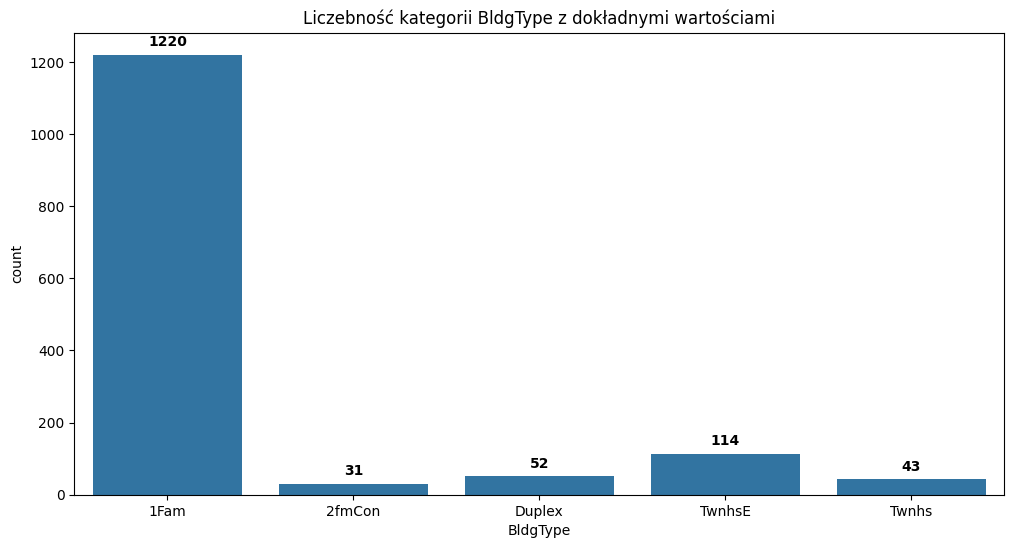

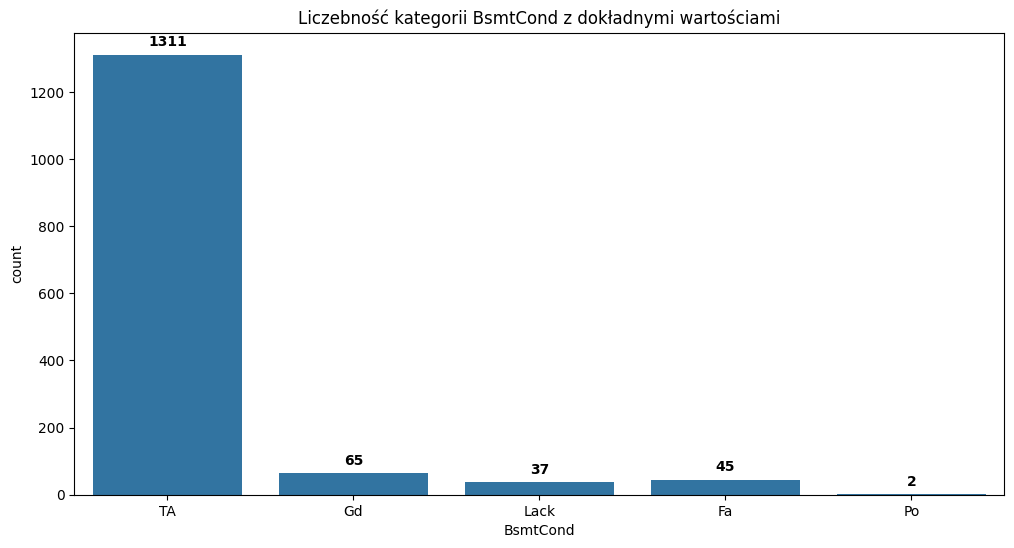

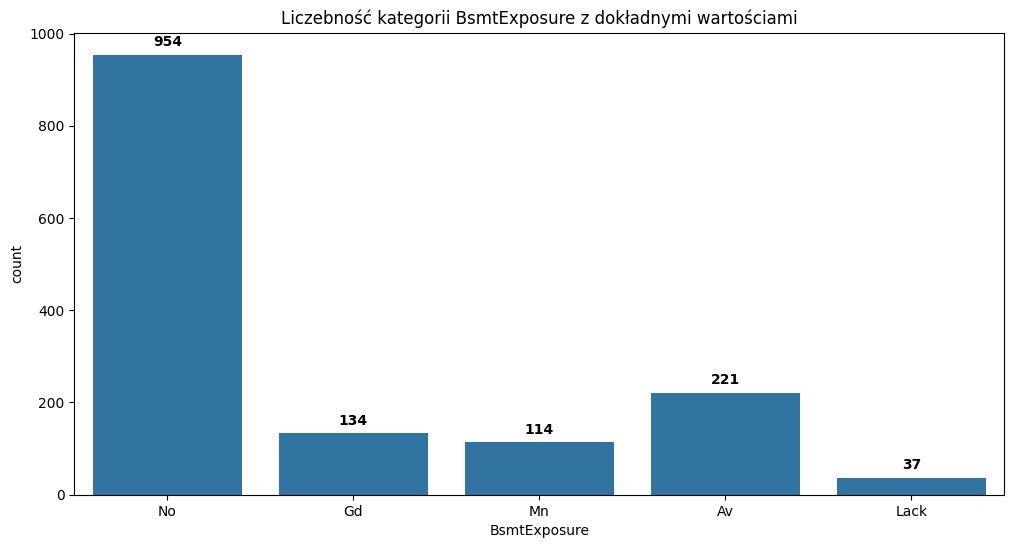

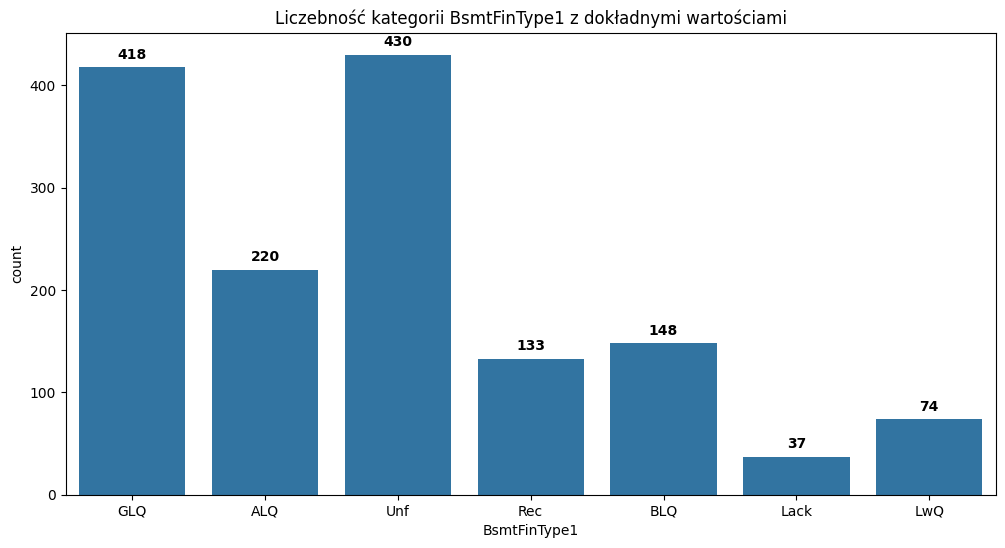

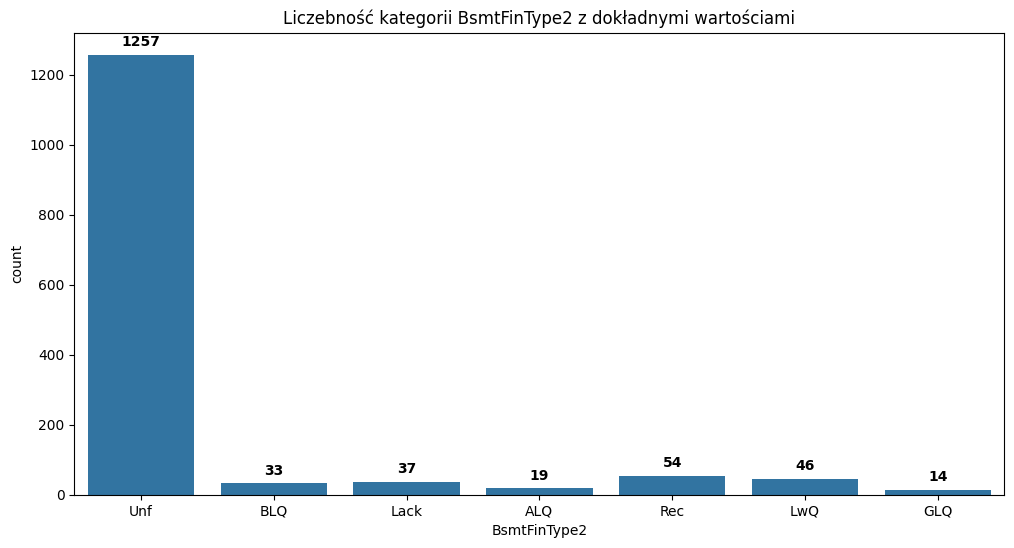

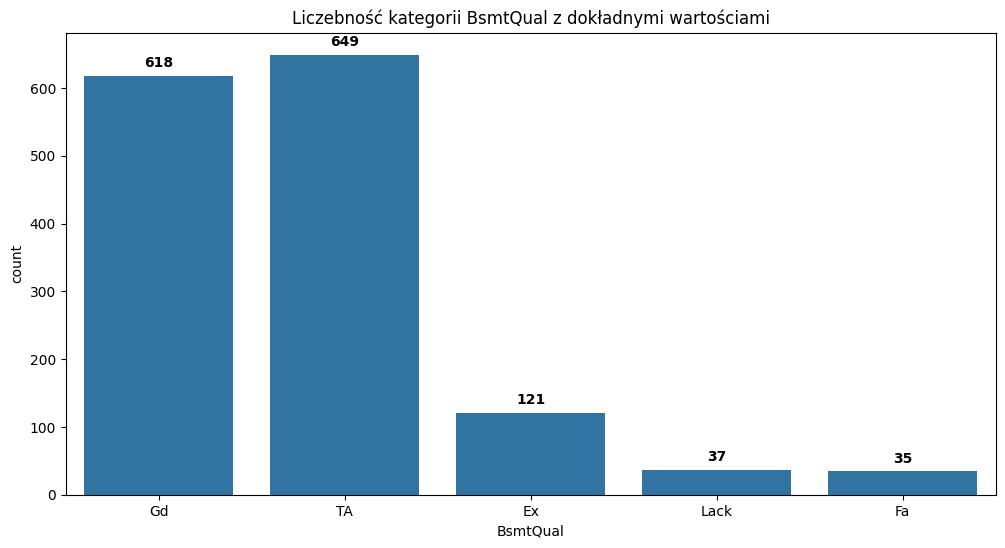

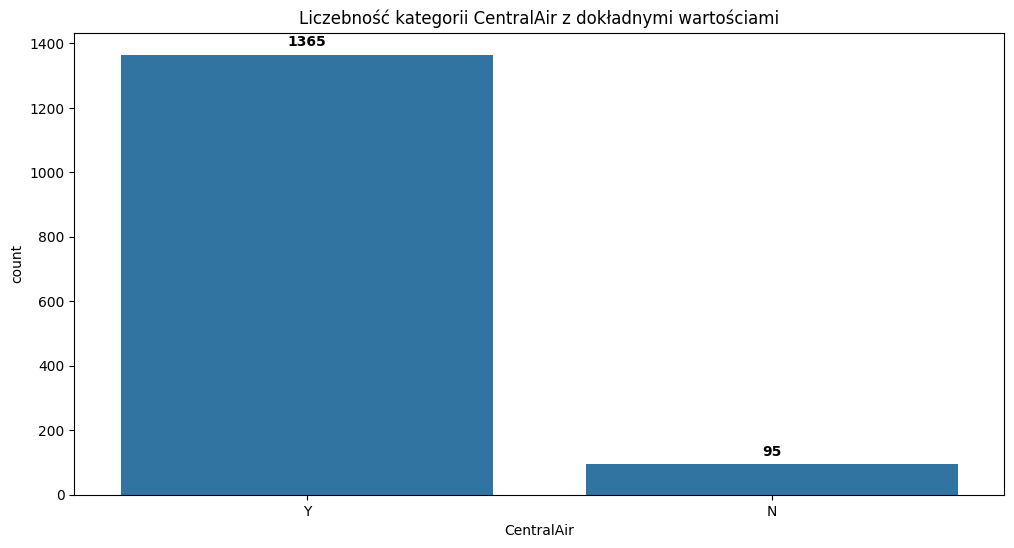

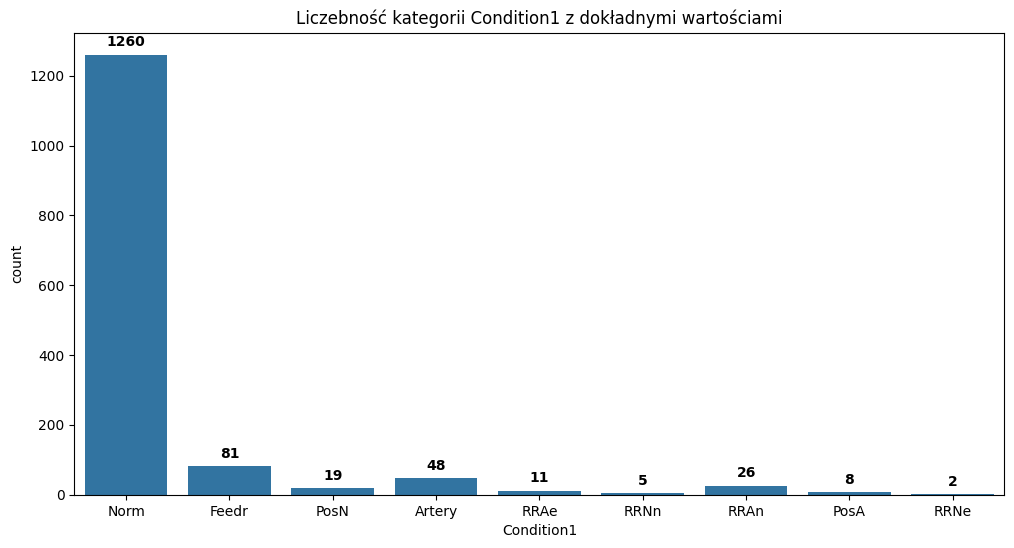

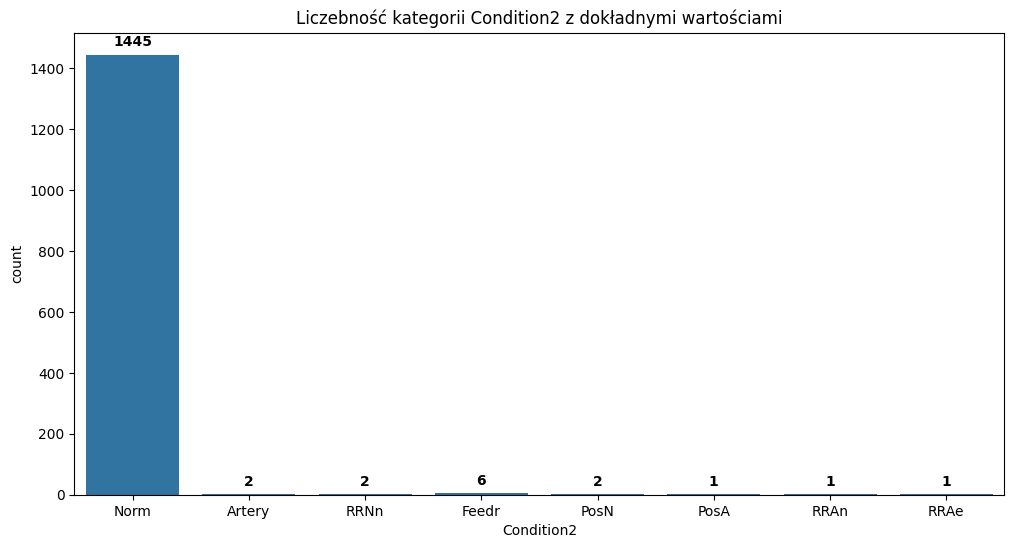

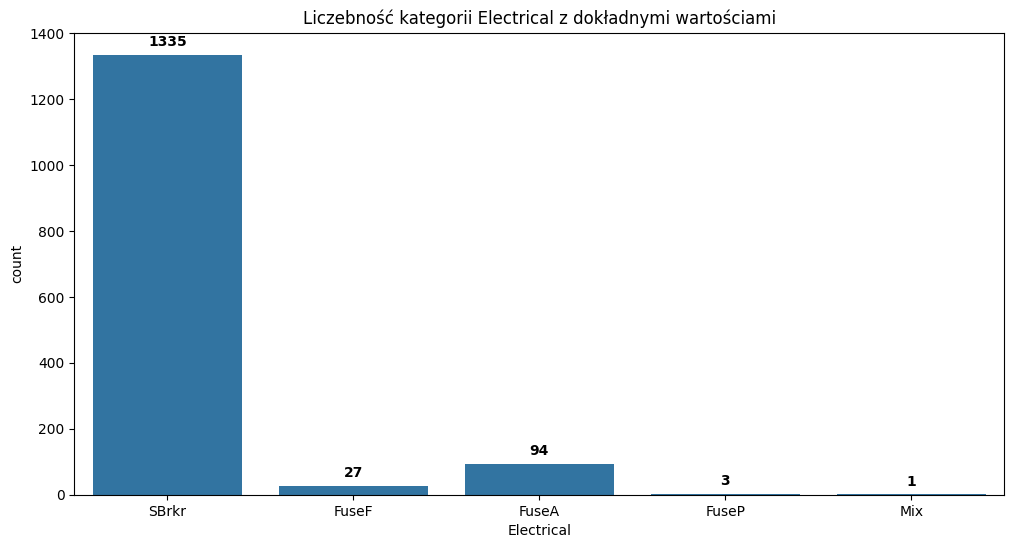

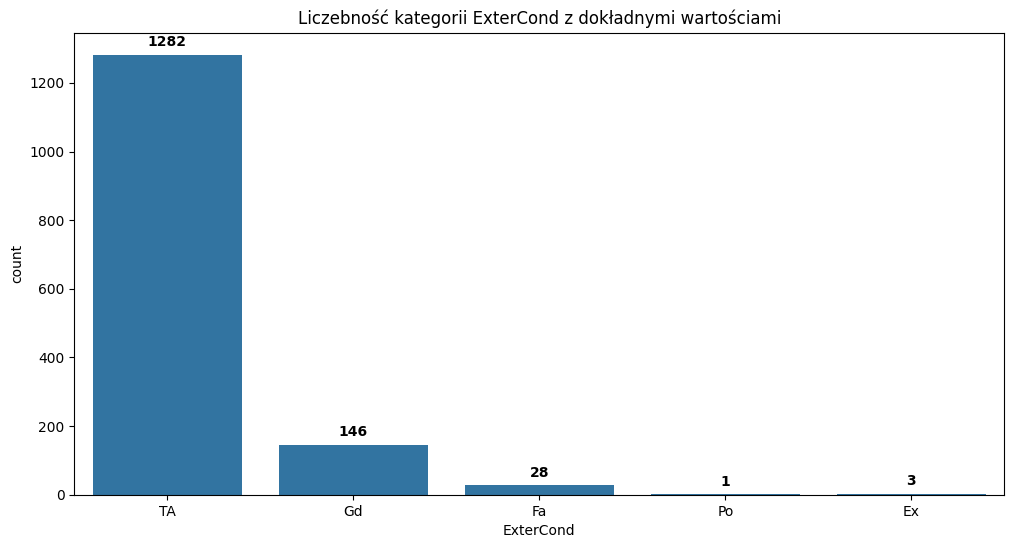

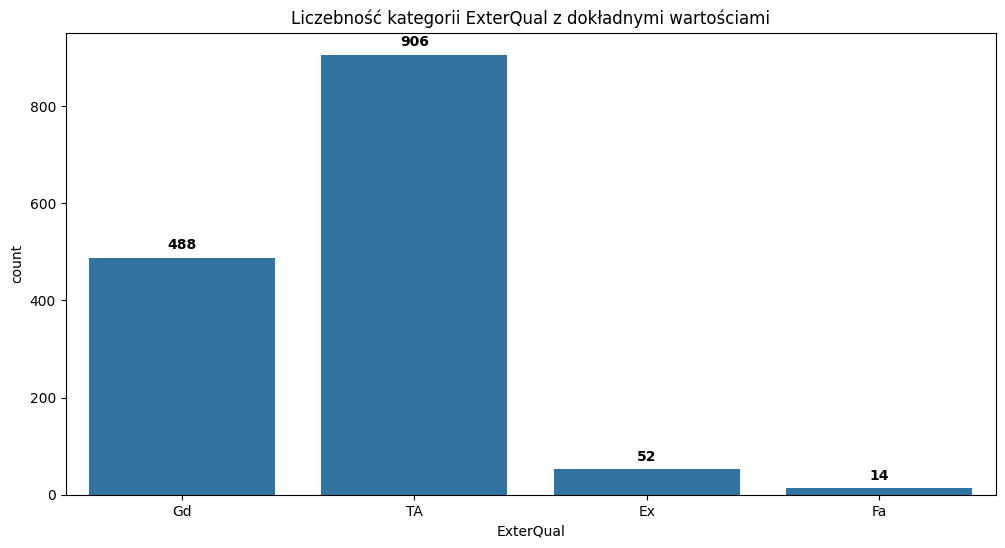

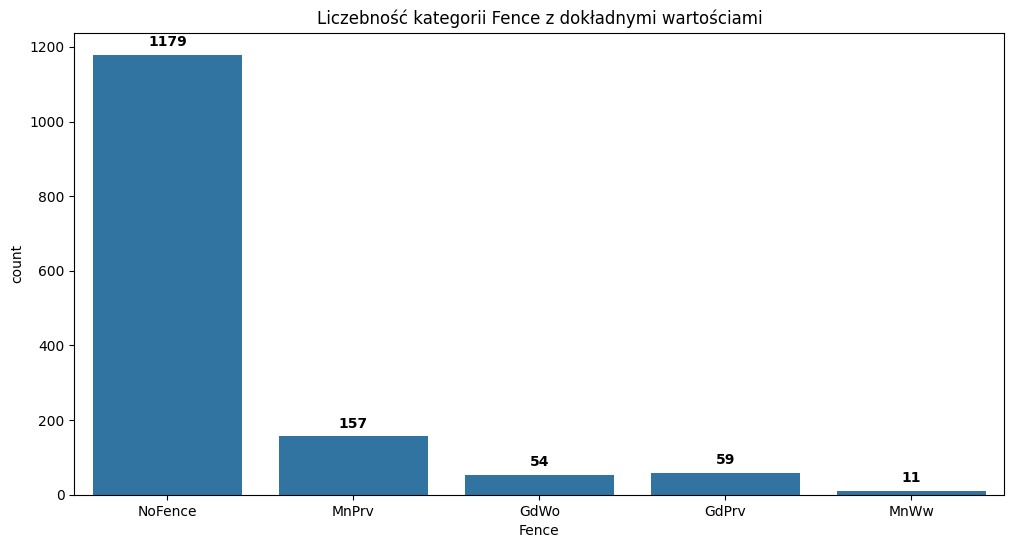

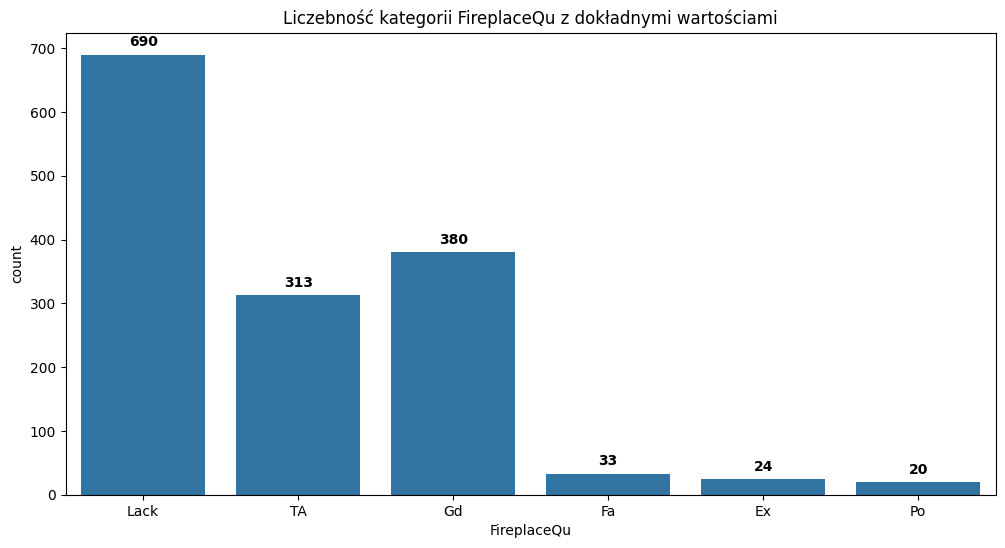

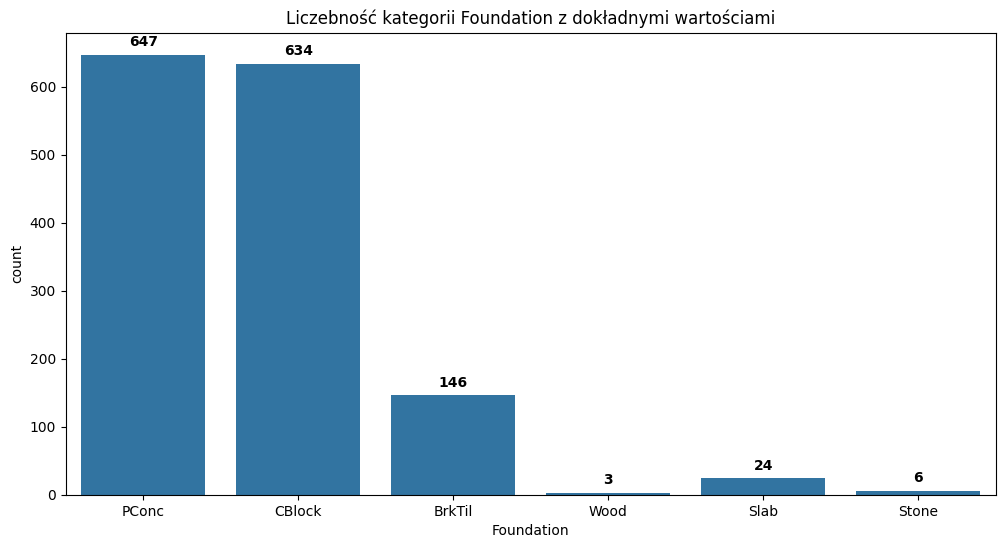

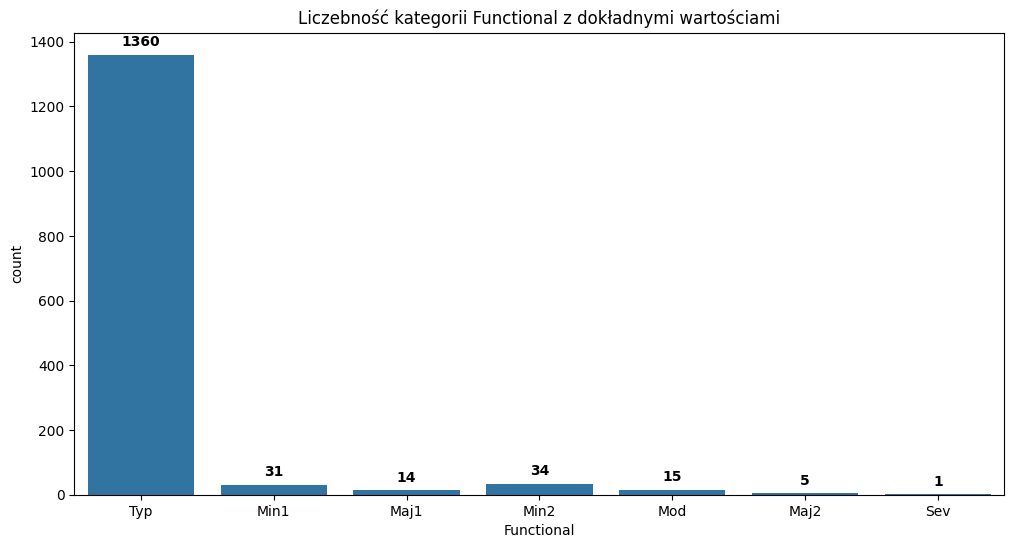

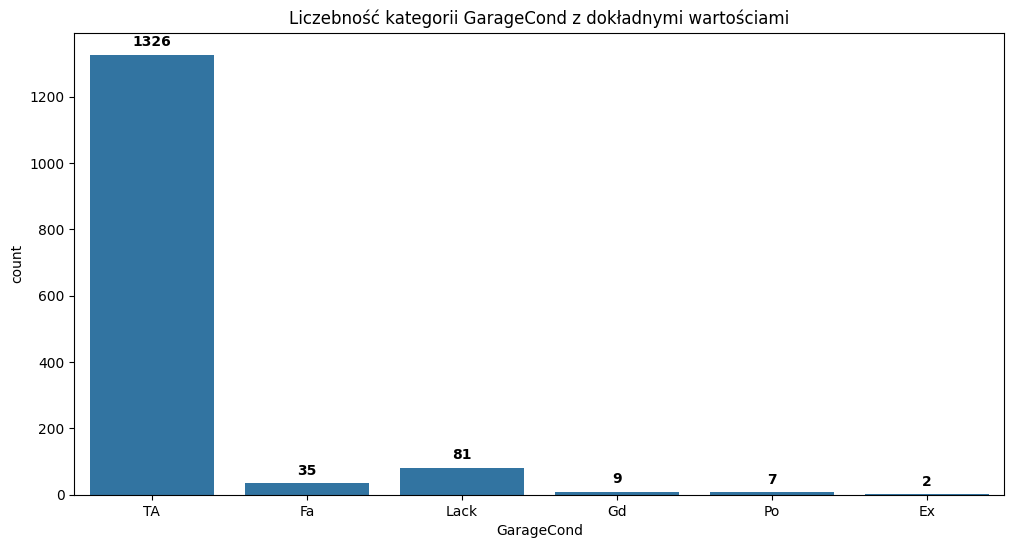

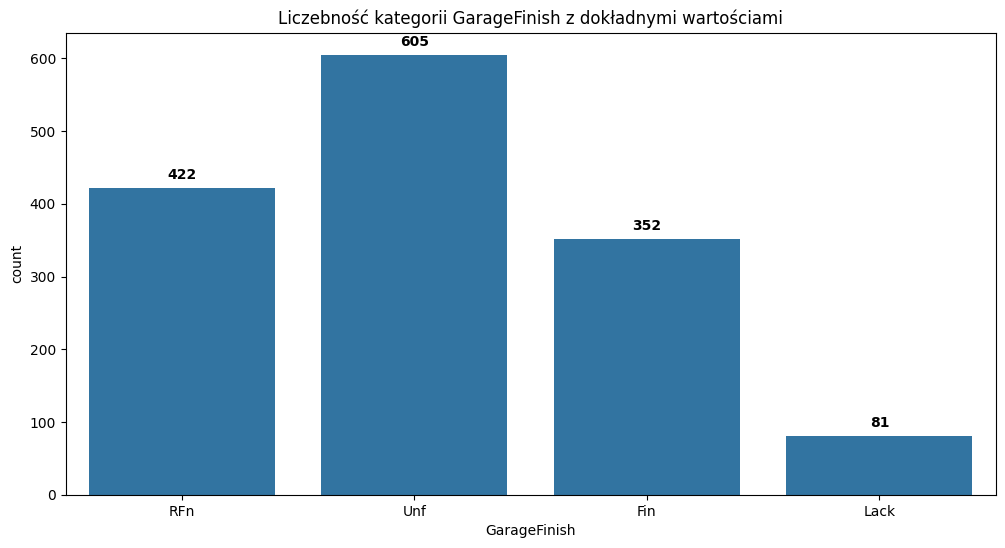

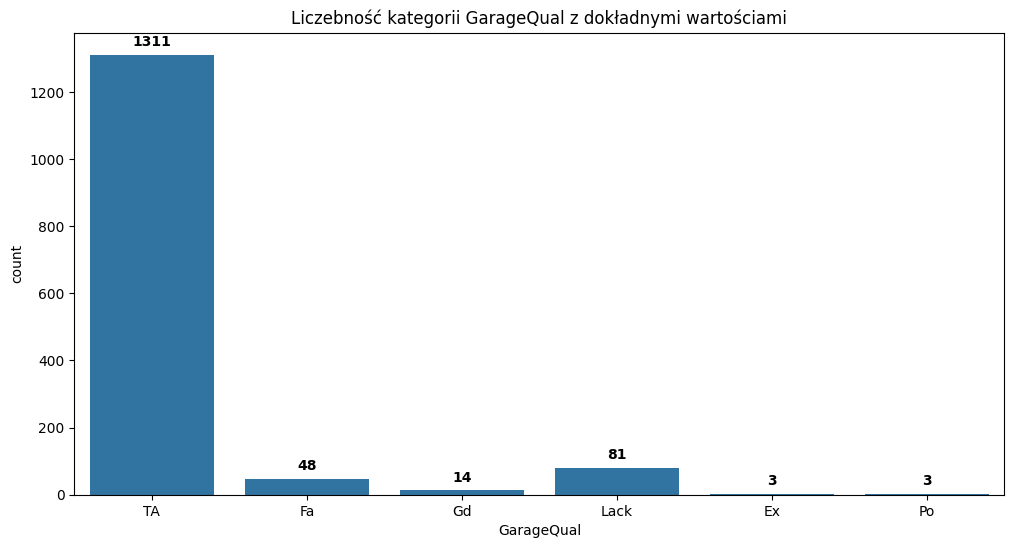

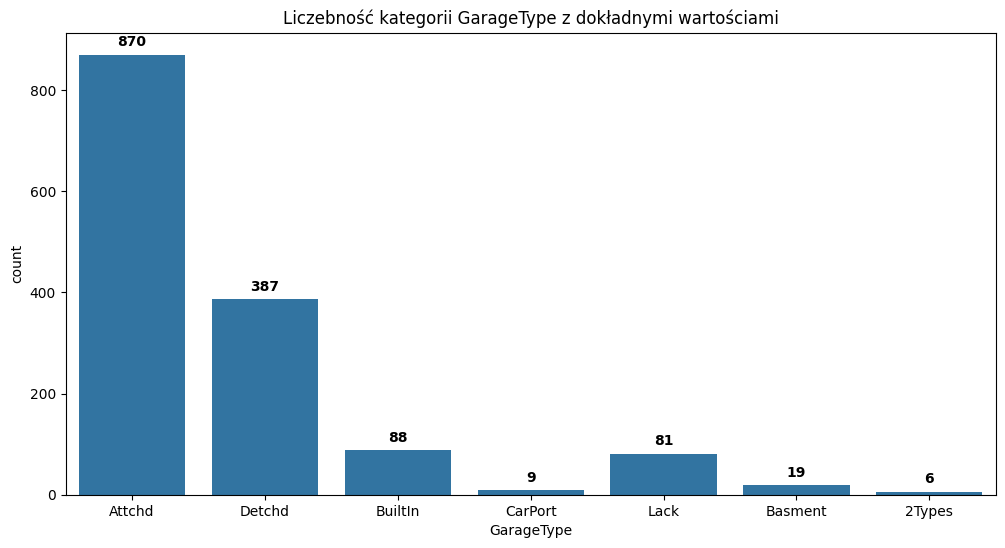

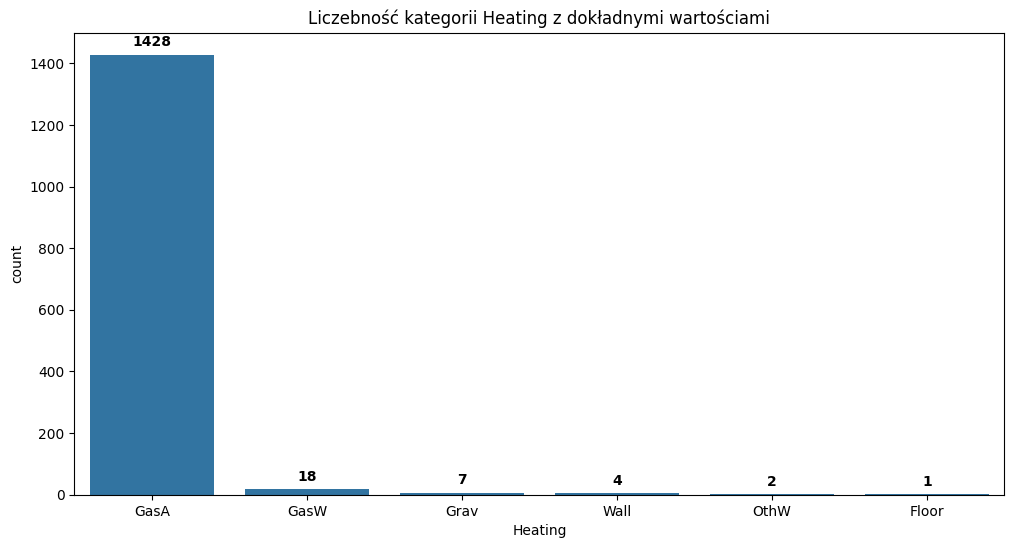

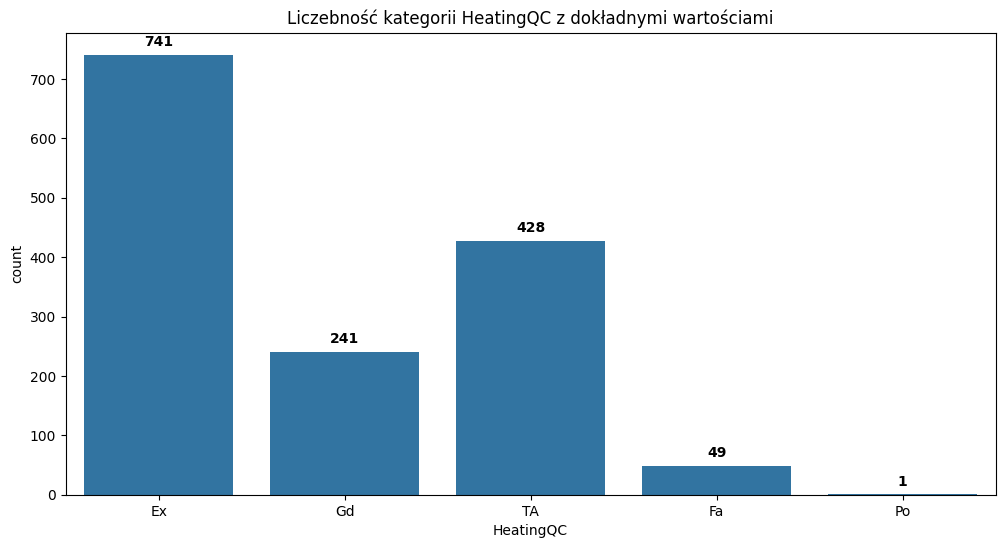

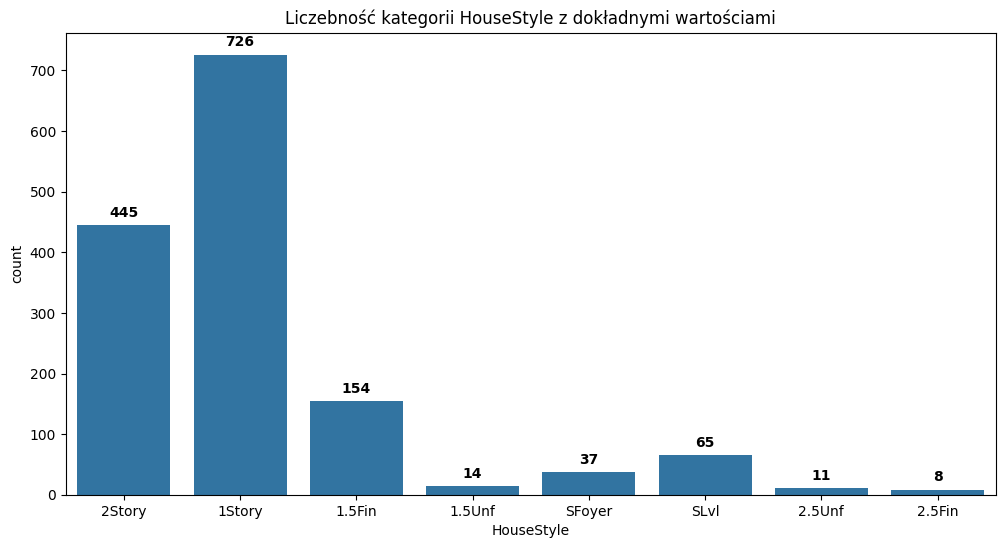

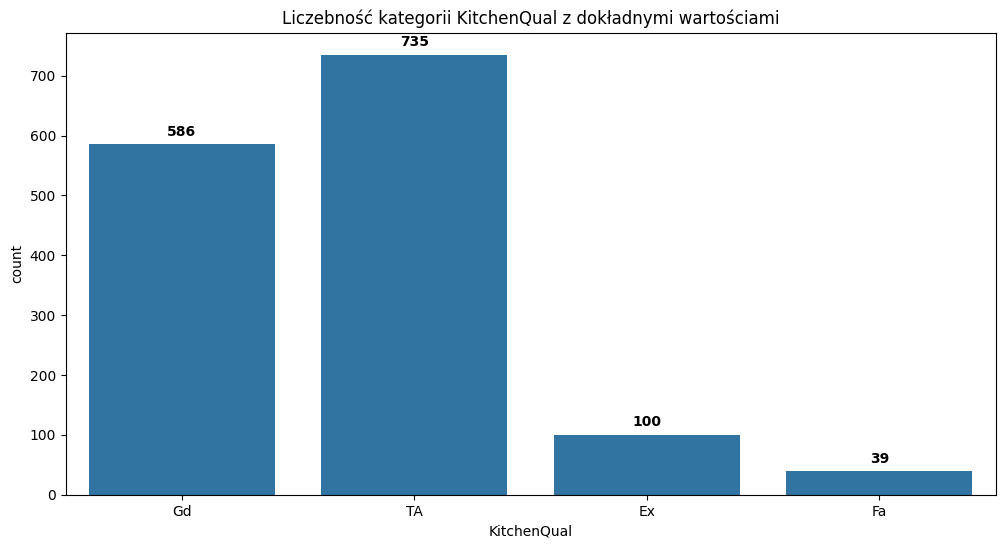

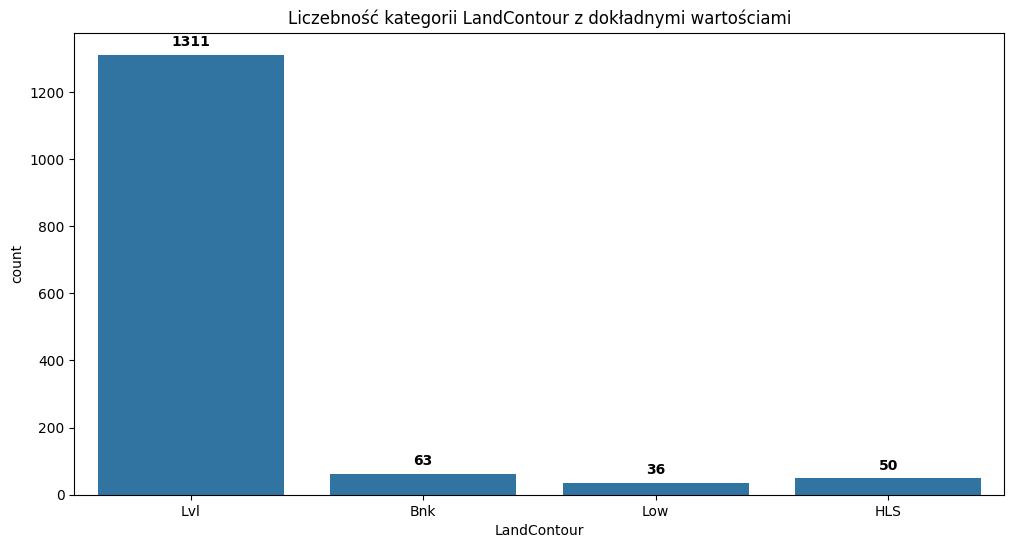

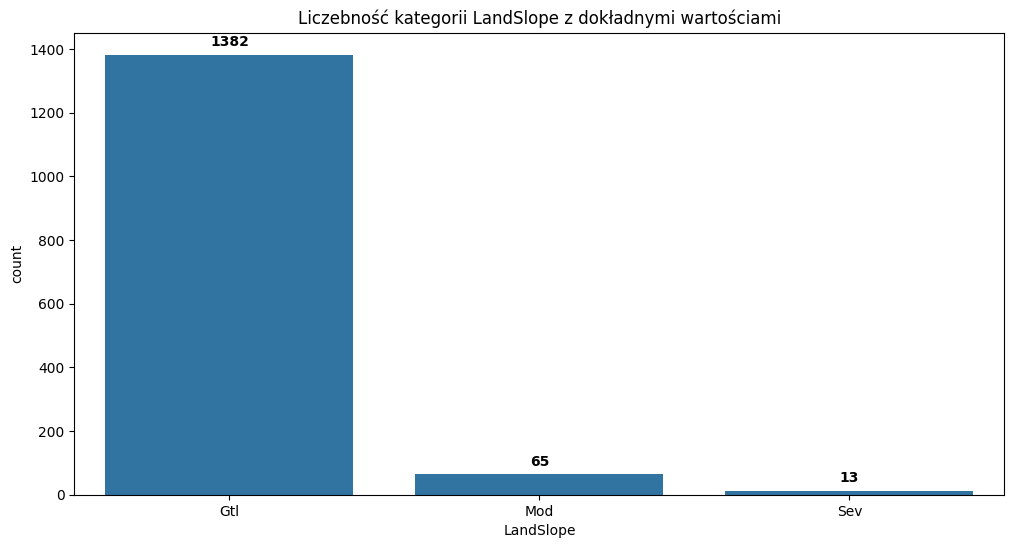

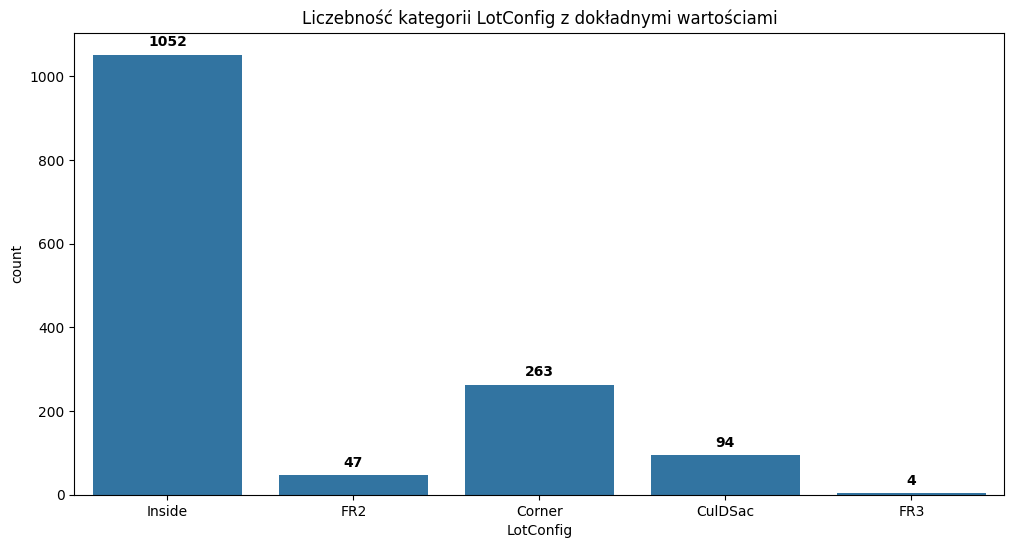

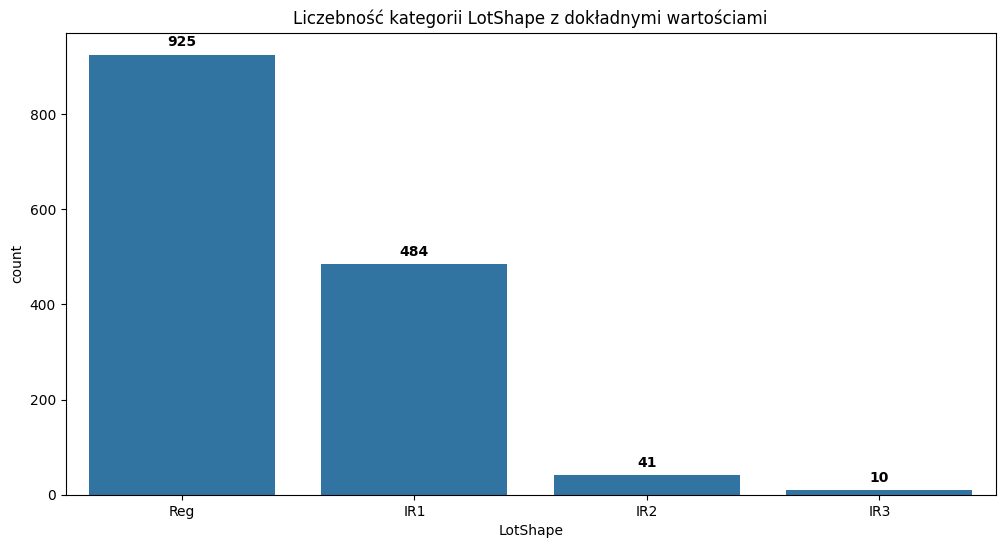

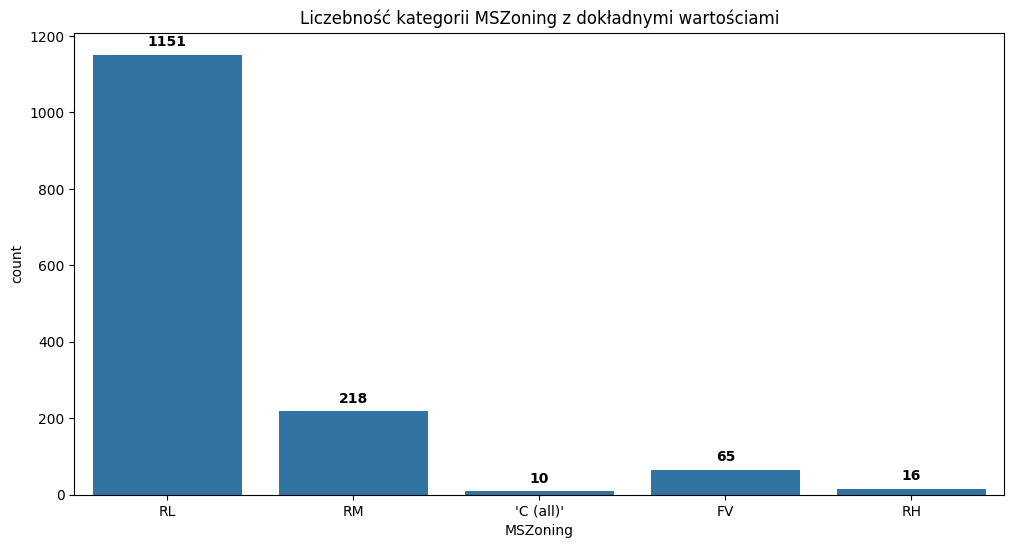

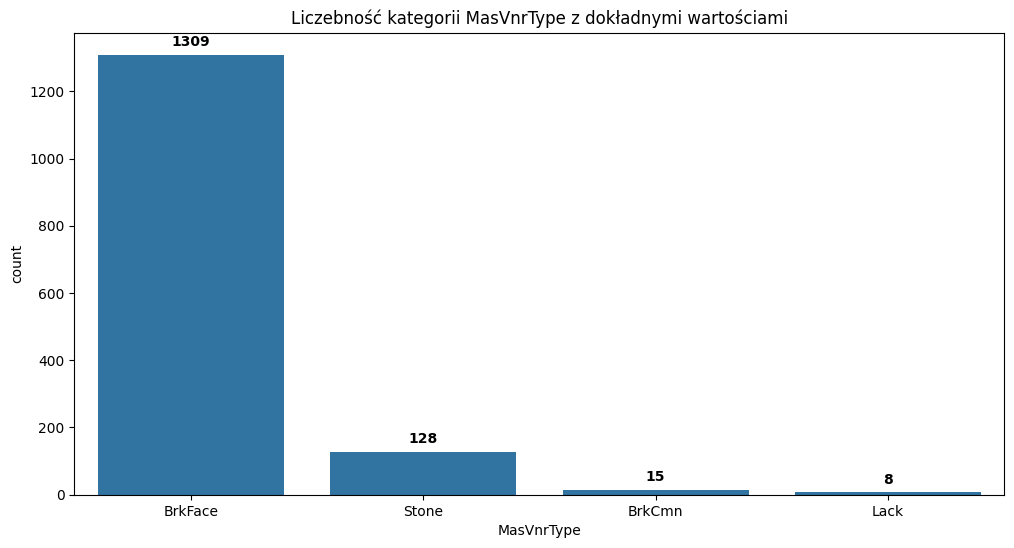

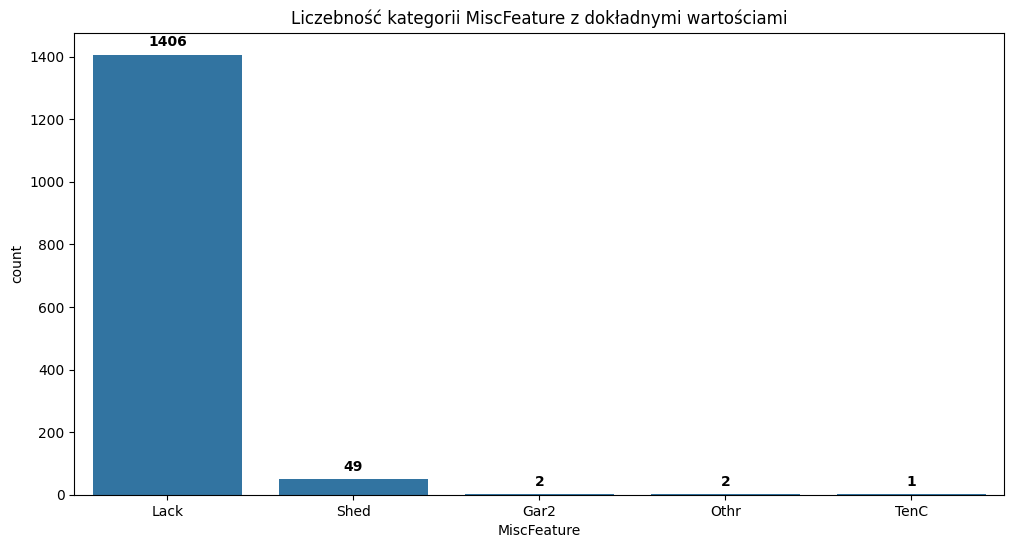

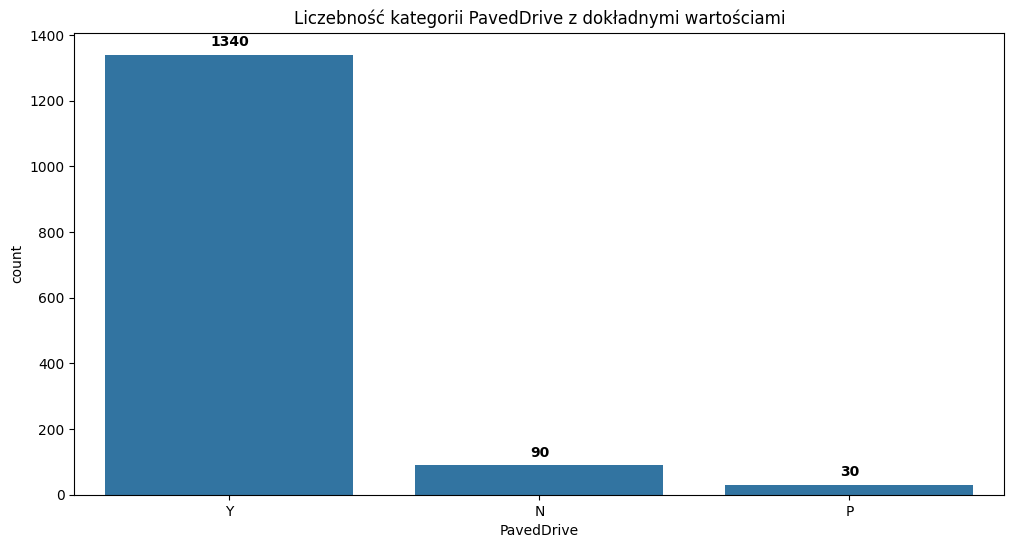

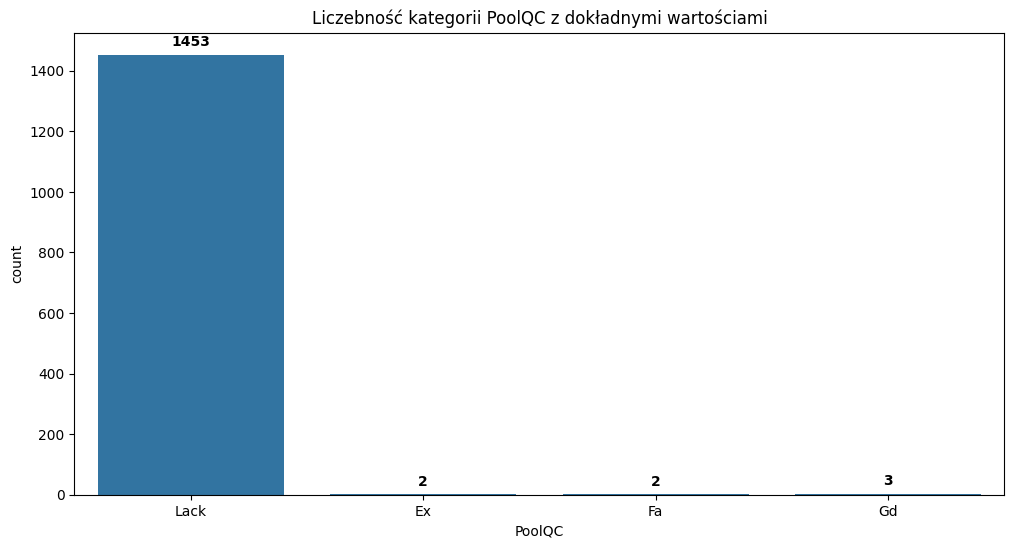

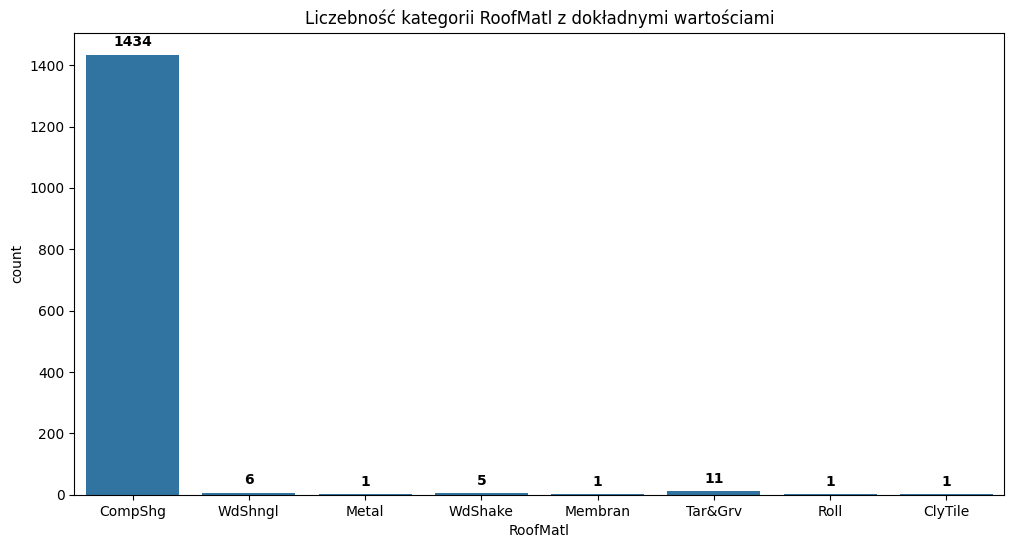

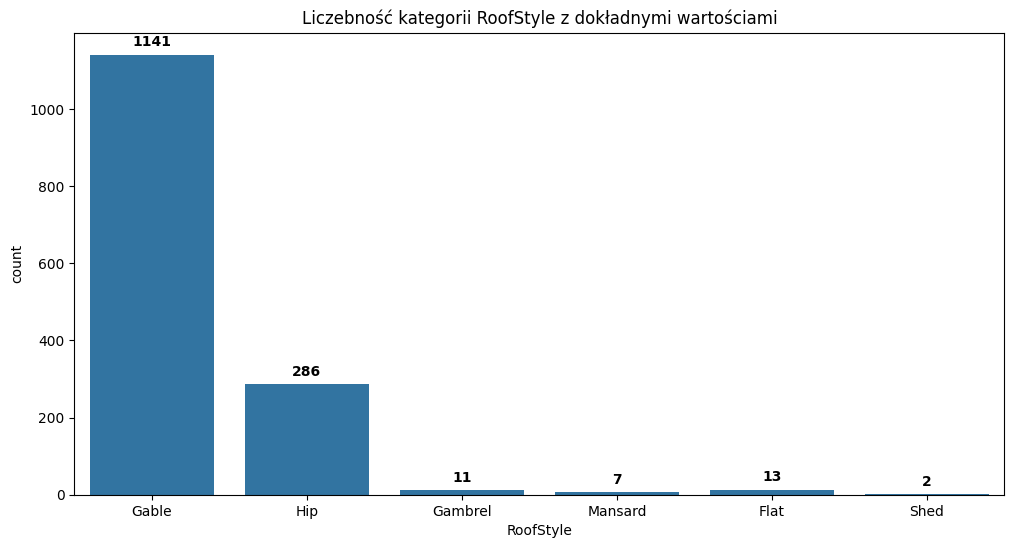

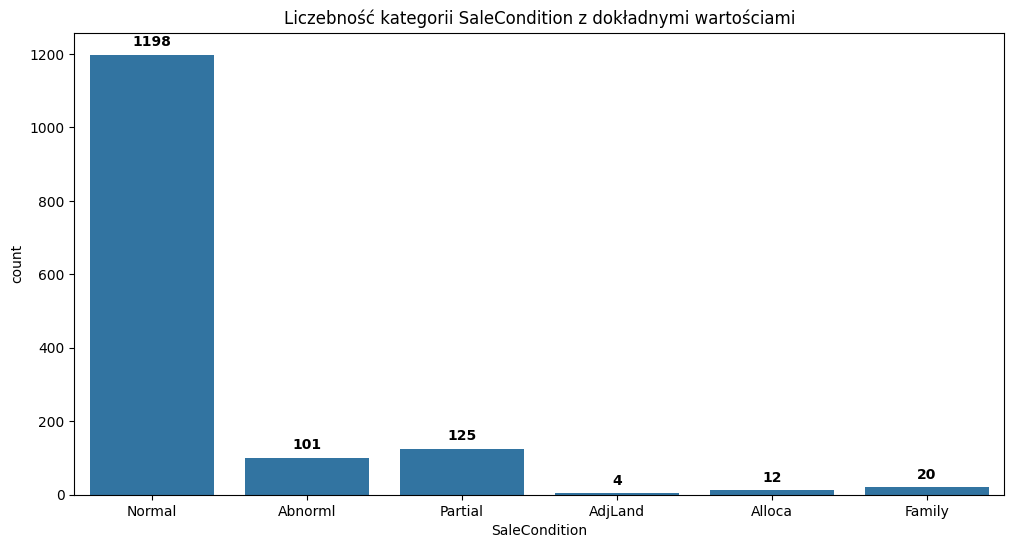

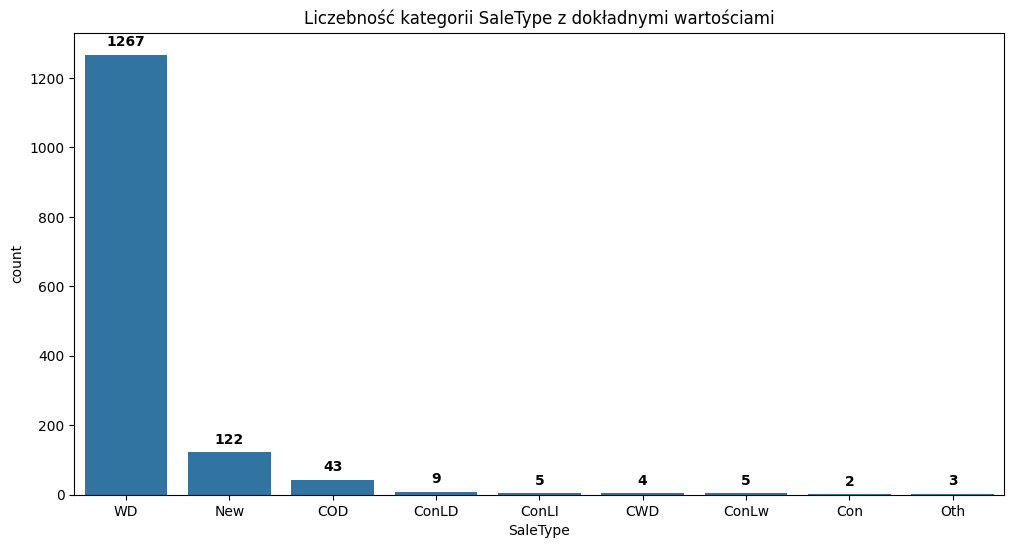

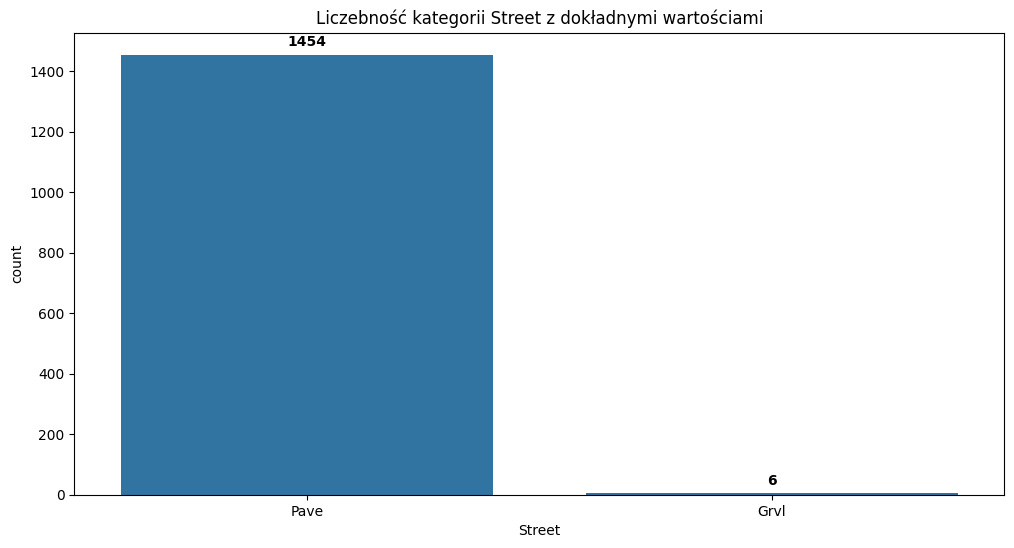

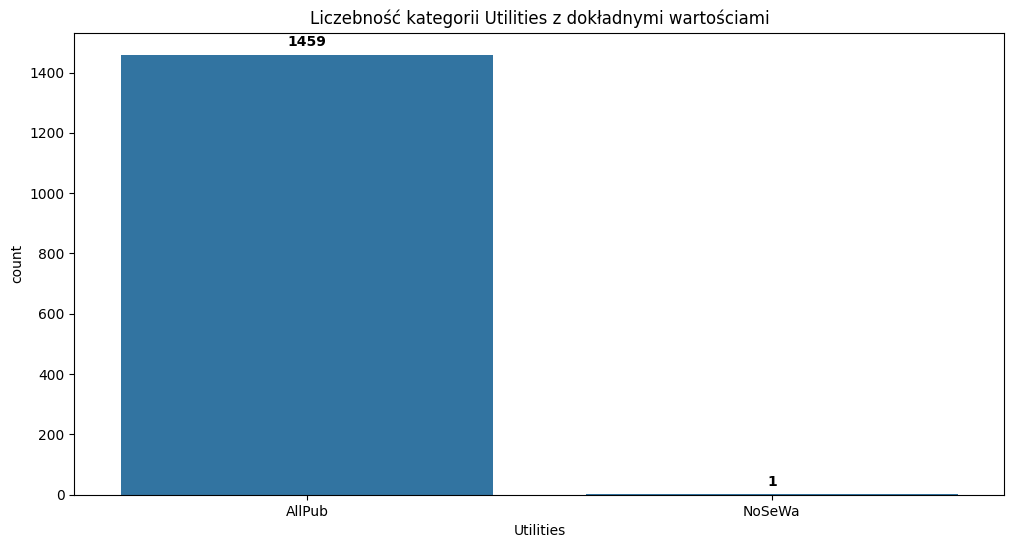

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
df_cat_s = df_cat_s.sort_index(axis=1)
for col in df_cat_s.columns:
    plt.figure(figsize=(12, 6))
    ax = sns.countplot(data=df_cat_s, x=col)
    
    # Dodawanie liczb nad słupkami
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.0f'), 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha = 'center', va = 'center', 
                       xytext = (0, 9), 
                       textcoords = 'offset points',
                       fontsize=10,
                       fontweight='bold')
    
    plt.title("Liczebność kategorii " + col + " z dokładnymi wartościami")
    plt.savefig("tabela_z_matplotlib.png", bbox_inches='tight', dpi=300)
    plt.show()

In [6]:
with pd.option_context('display.max_rows', None):
    print(df['MiscFeature'])

0       Lack
1       Lack
2       Lack
3       Lack
4       Lack
5       Shed
6       Lack
7       Shed
8       Lack
9       Lack
10      Lack
11      Lack
12      Lack
13      Lack
14      Lack
15      Lack
16      Shed
17      Shed
18      Lack
19      Lack
20      Lack
21      Lack
22      Lack
23      Lack
24      Lack
25      Lack
26      Lack
27      Lack
28      Lack
29      Lack
30      Lack
31      Lack
32      Lack
33      Lack
34      Lack
35      Lack
36      Lack
37      Lack
38      Lack
39      Lack
40      Lack
41      Lack
42      Lack
43      Lack
44      Lack
45      Lack
46      Lack
47      Lack
48      Lack
49      Lack
50      Lack
51      Shed
52      Lack
53      Lack
54      Lack
55      Lack
56      Lack
57      Lack
58      Lack
59      Lack
60      Lack
61      Lack
62      Lack
63      Lack
64      Lack
65      Lack
66      Lack
67      Lack
68      Lack
69      Lack
70      Lack
71      Lack
72      Lack
73      Lack
74      Lack
75      Lack
76      Lack

In [7]:
braki = df.isna().sum()

# Wyświetlamy tylko te kolumny, gdzie liczba braków jest > 0
print(braki[braki > 0])

Series([], dtype: int64)


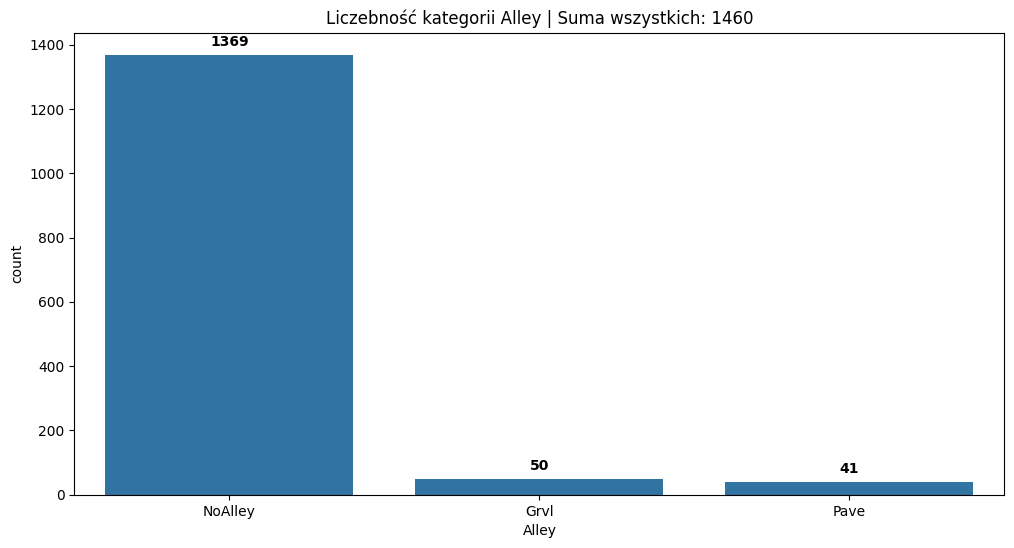

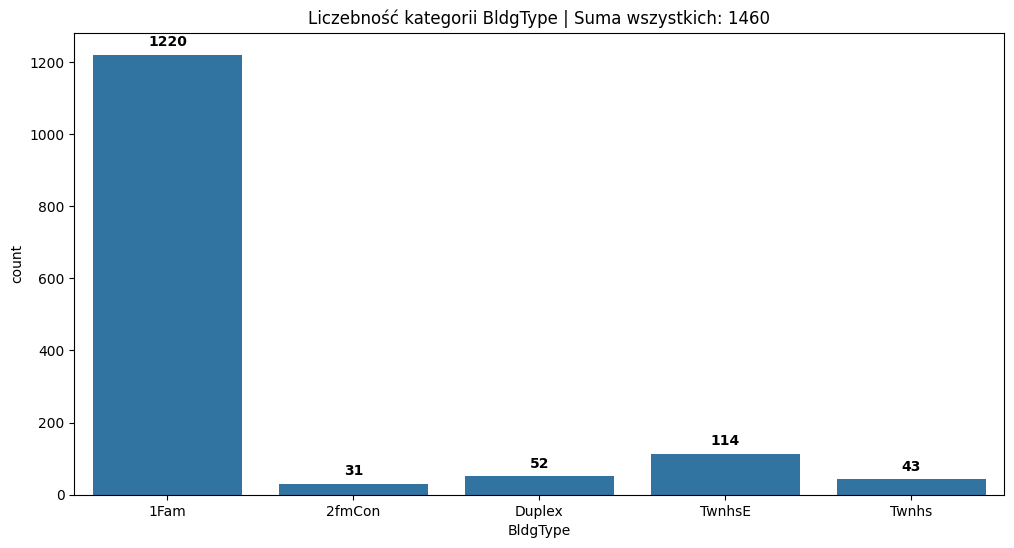

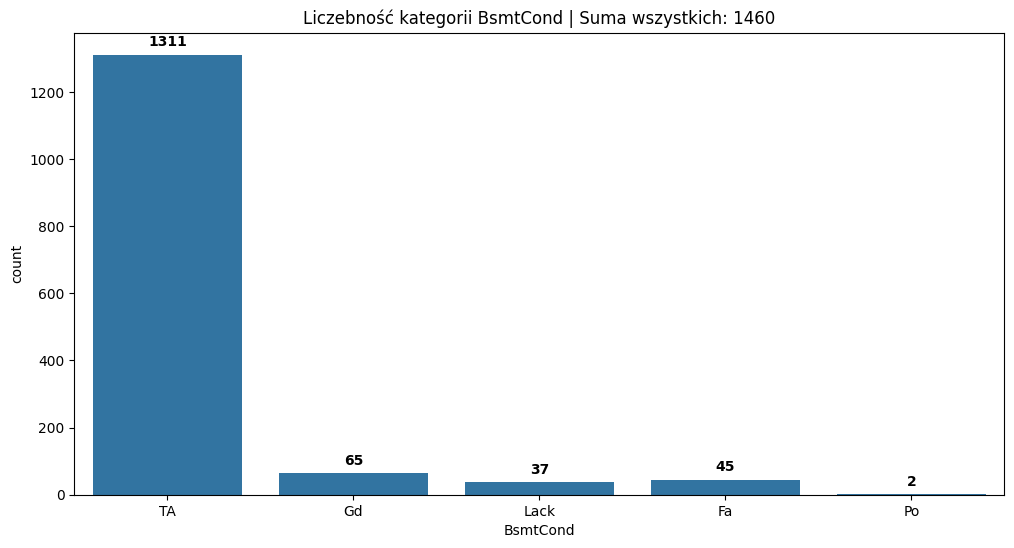

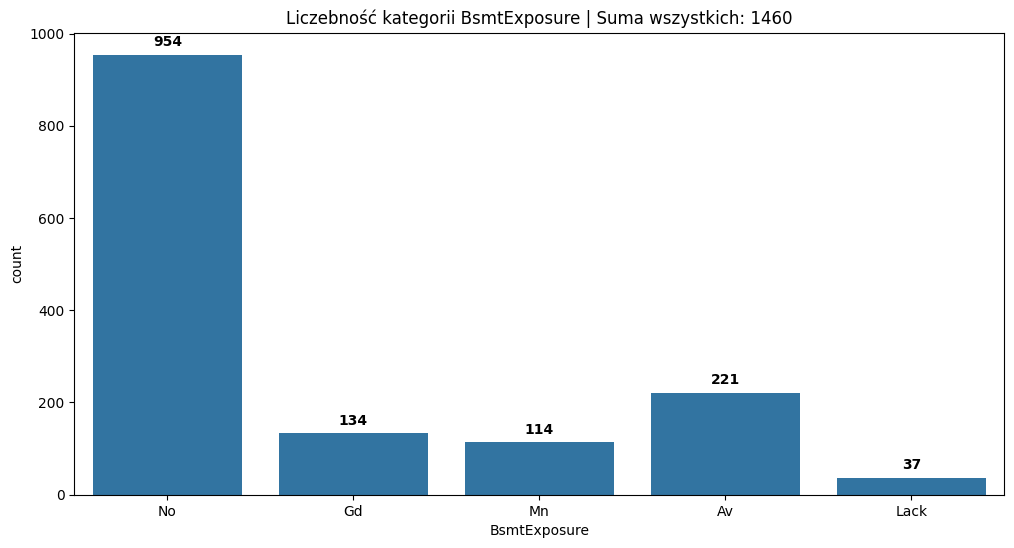

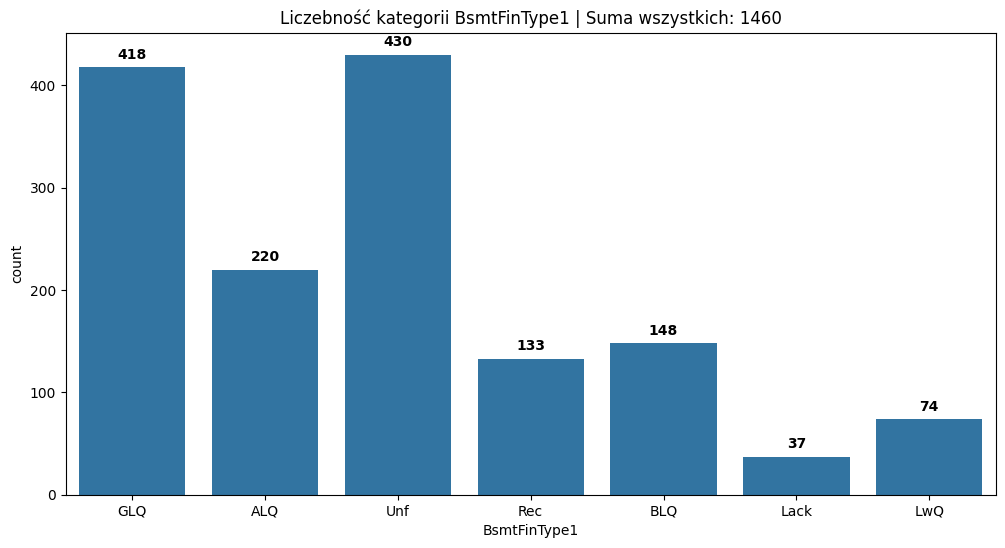

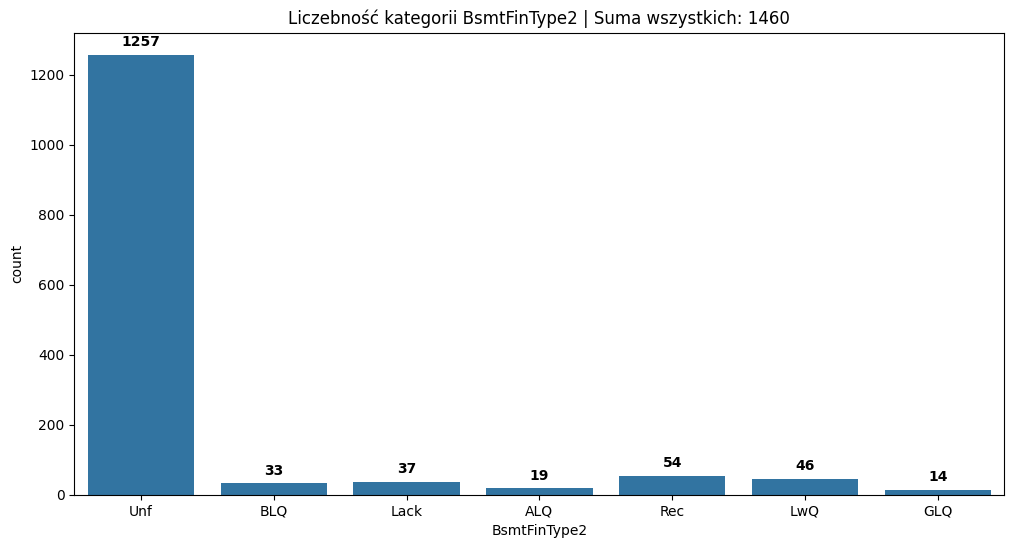

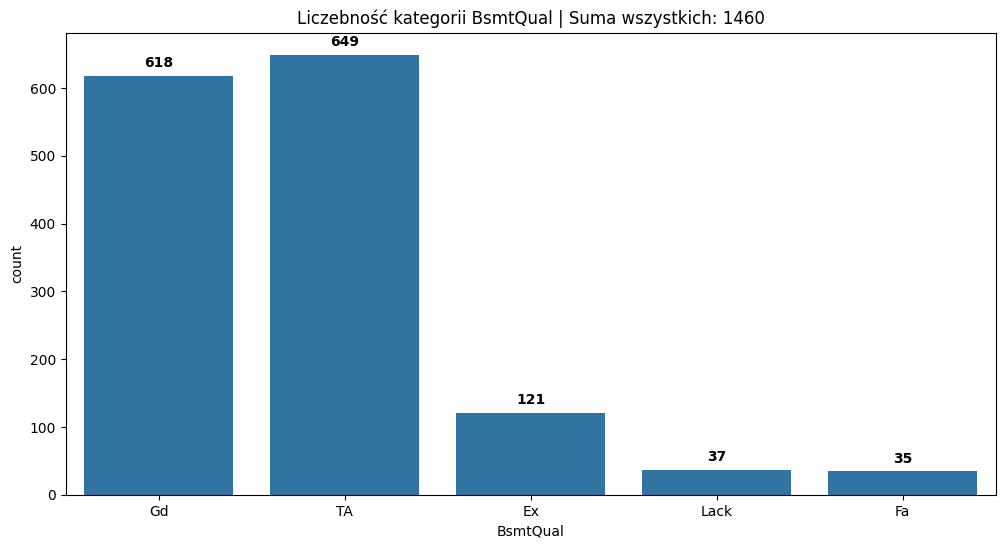

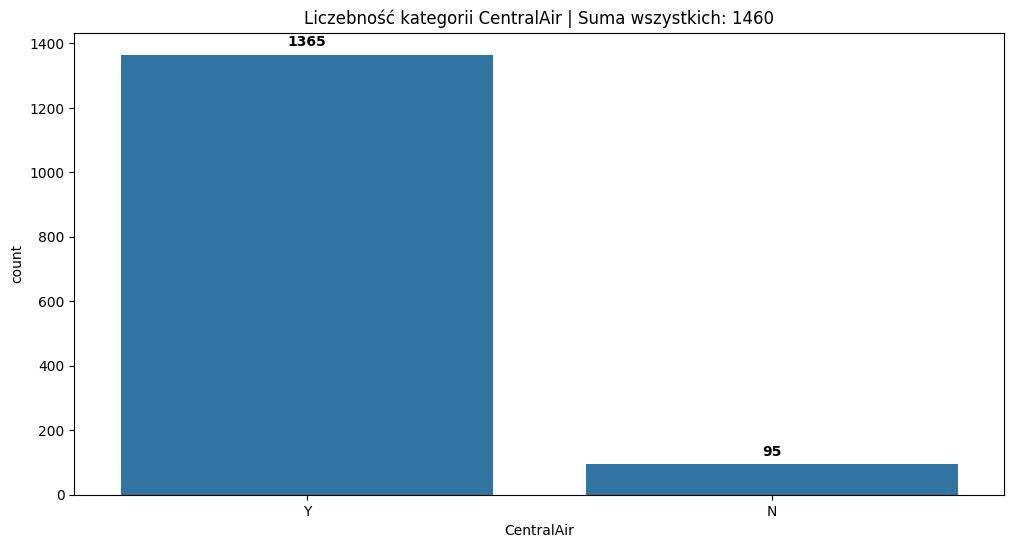

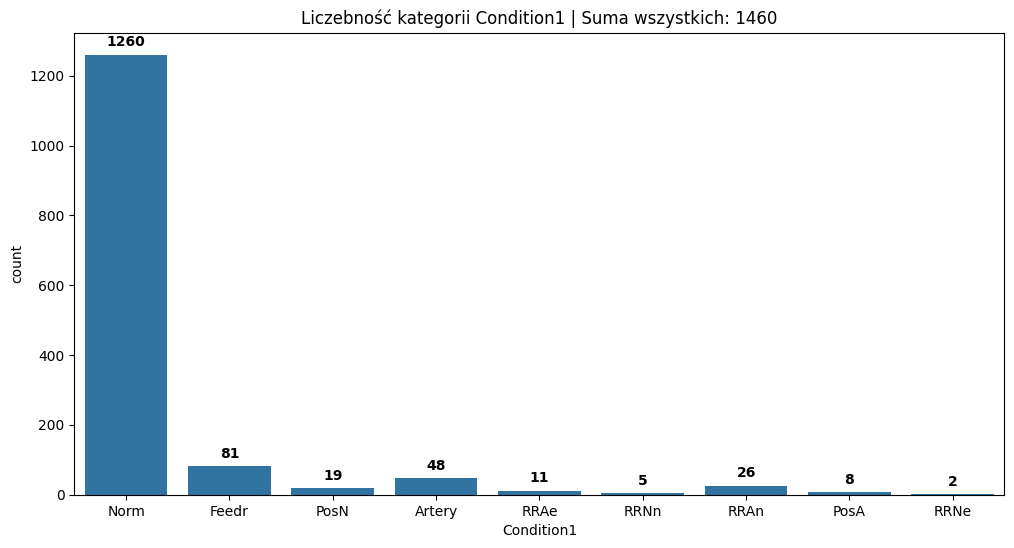

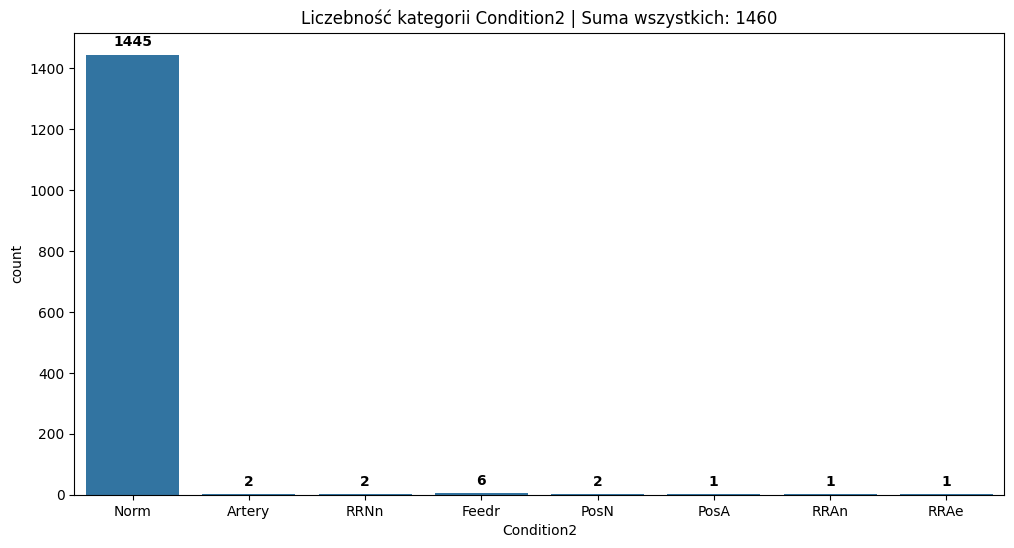

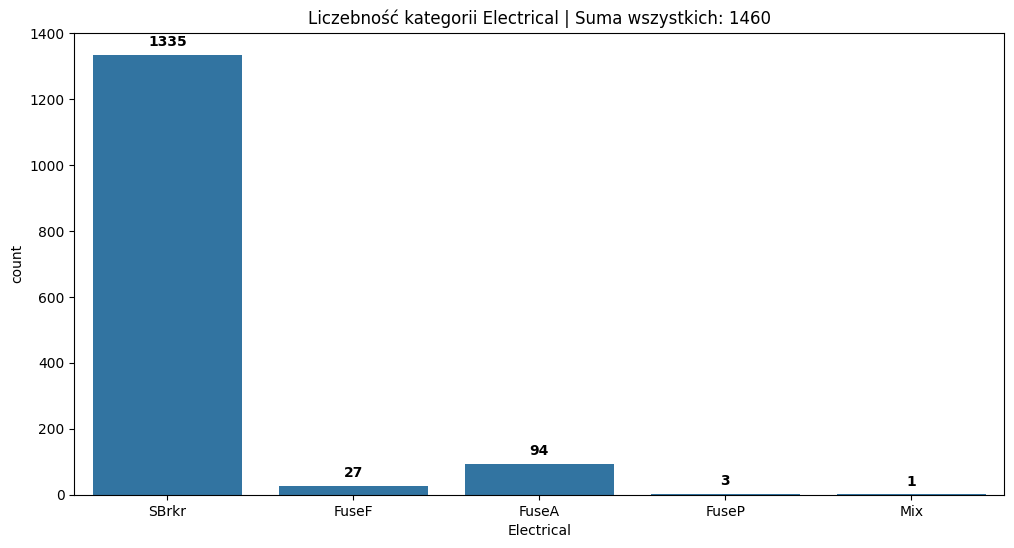

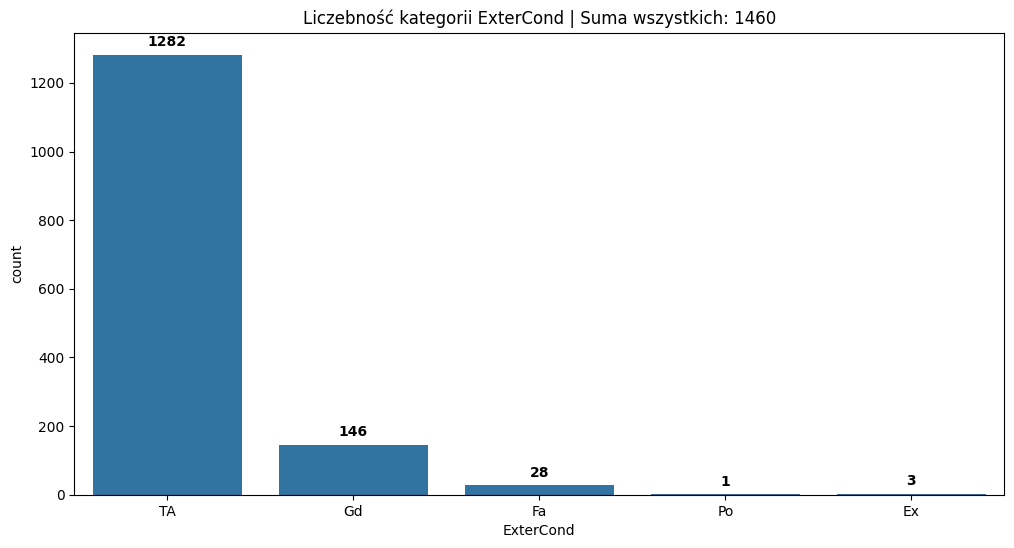

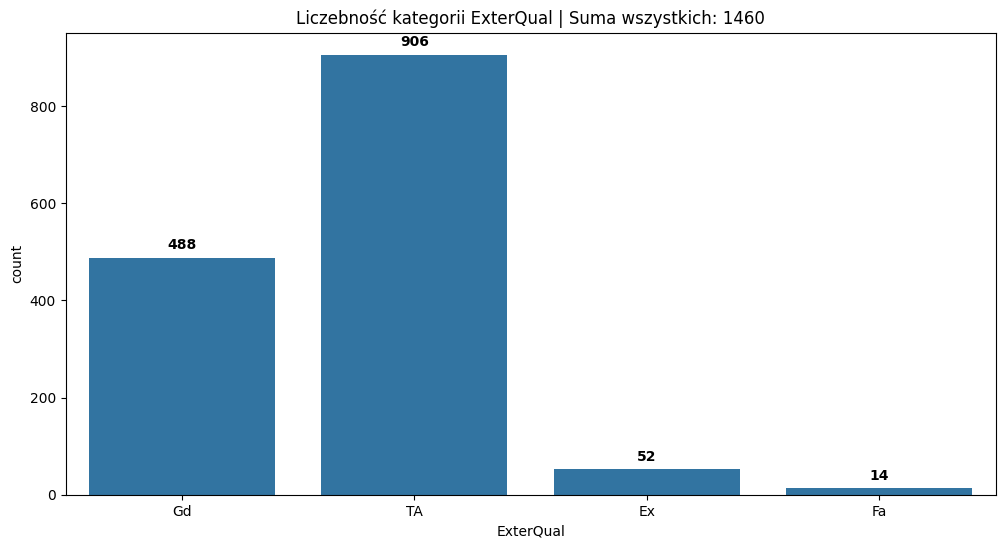

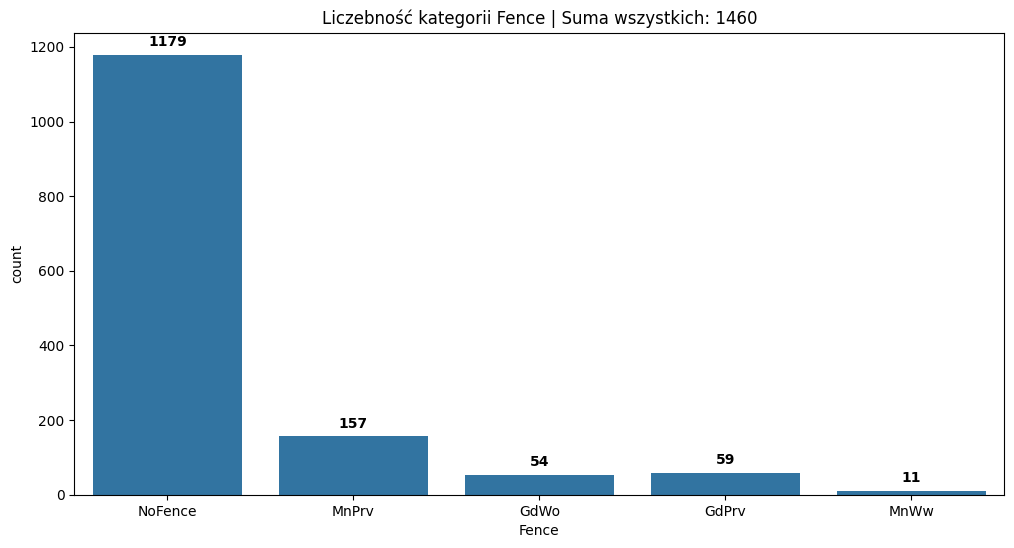

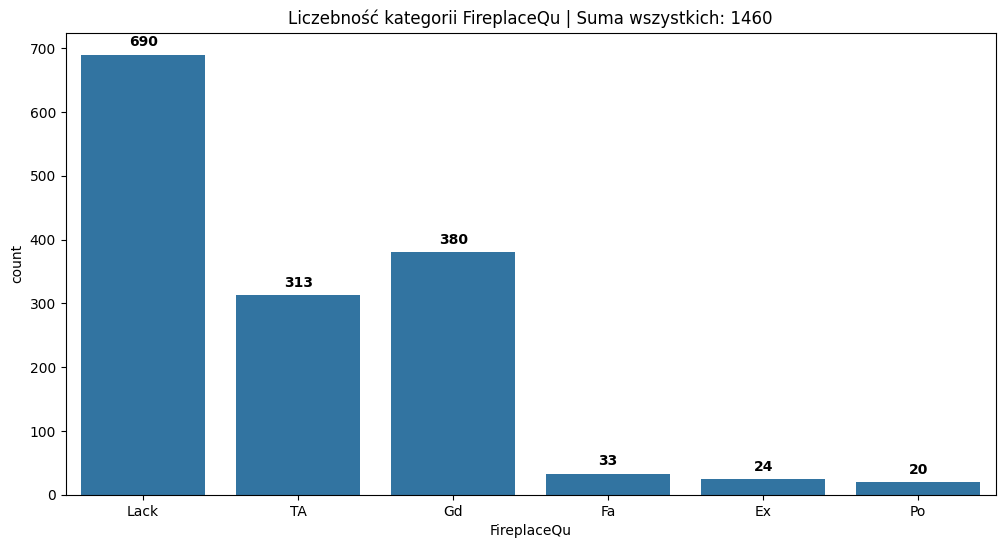

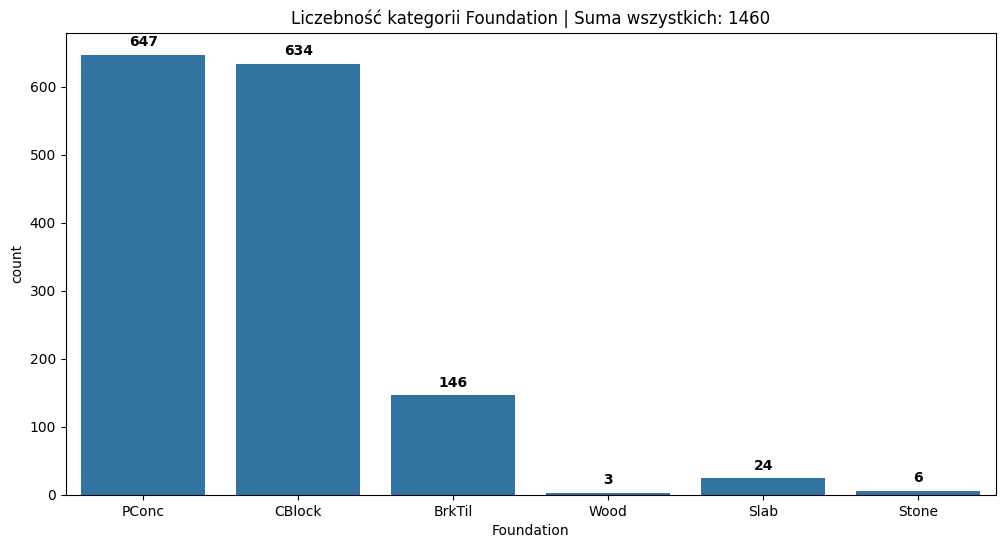

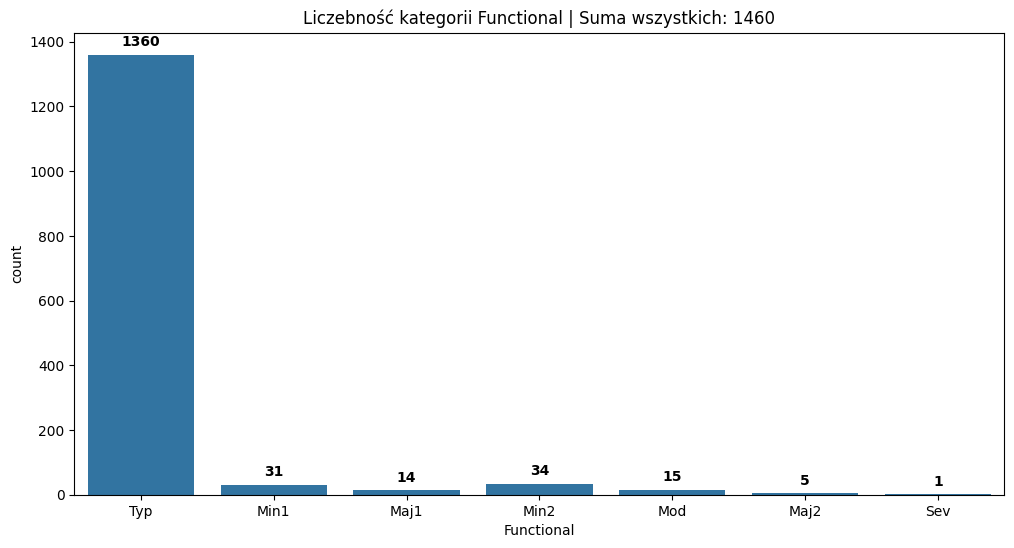

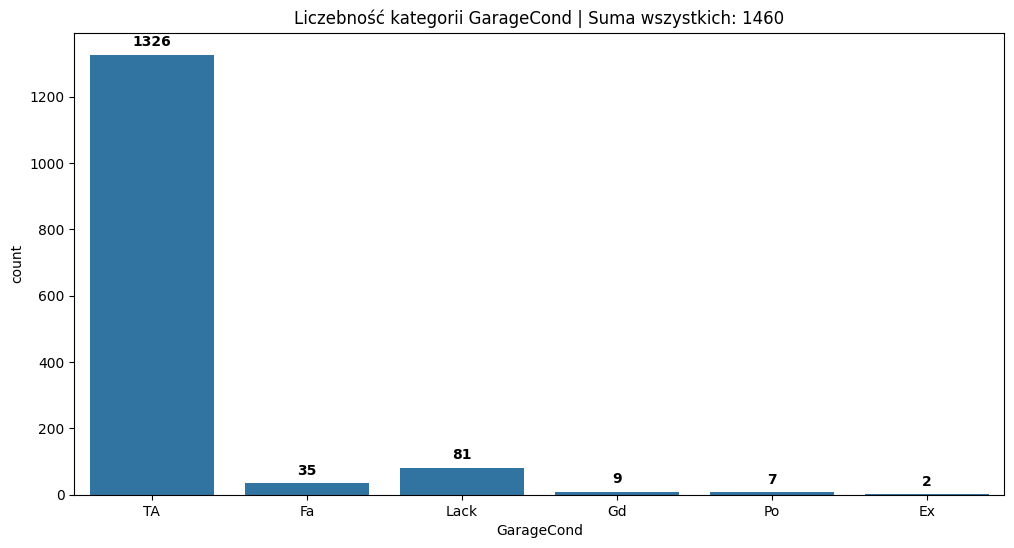

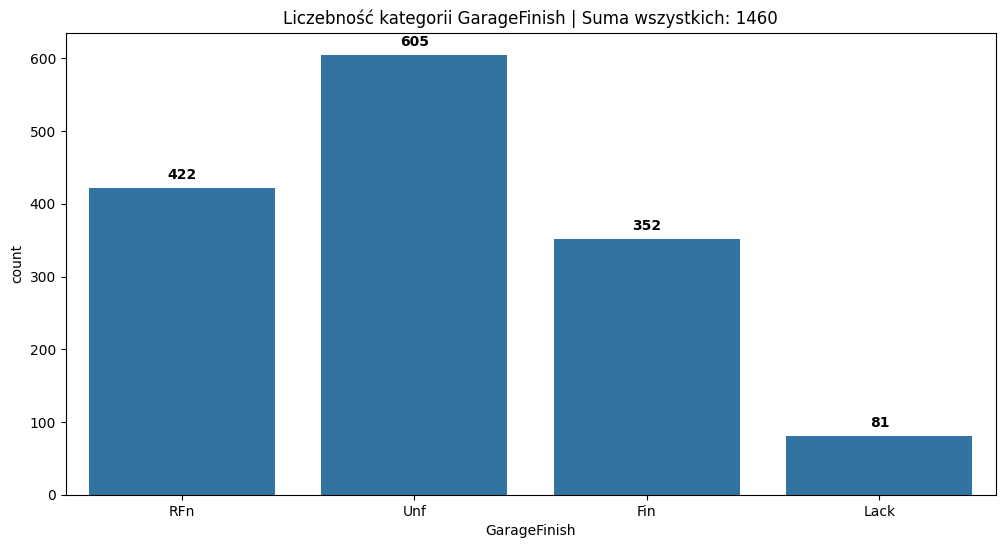

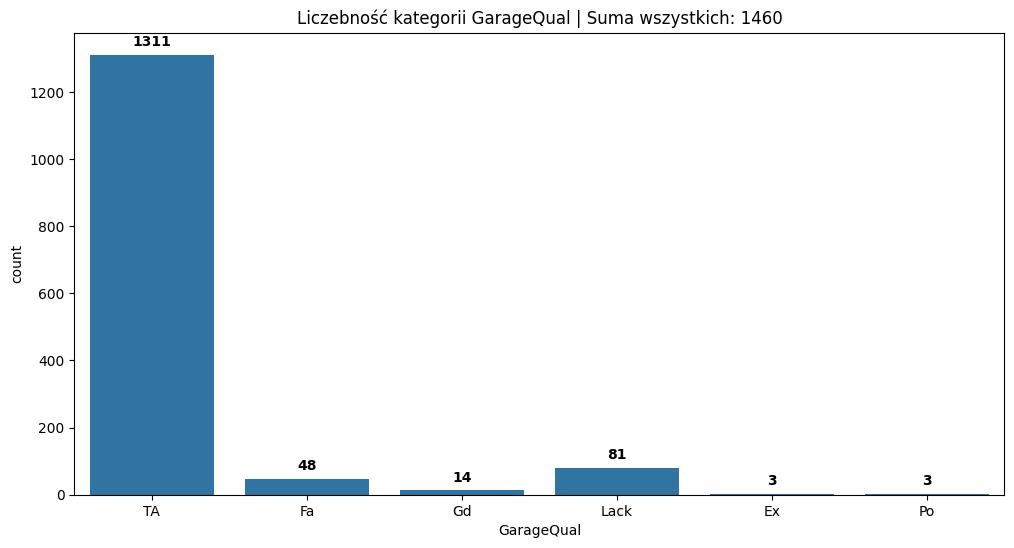

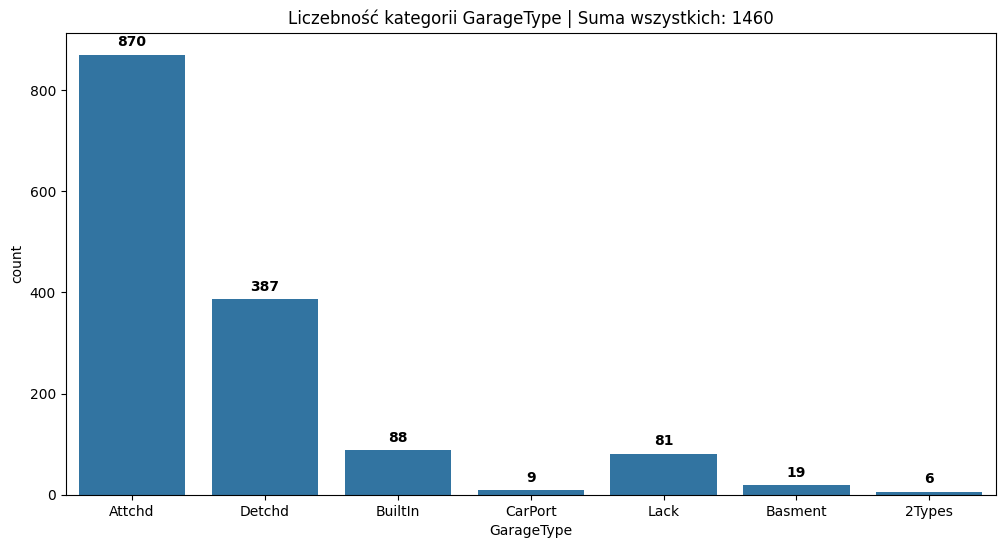

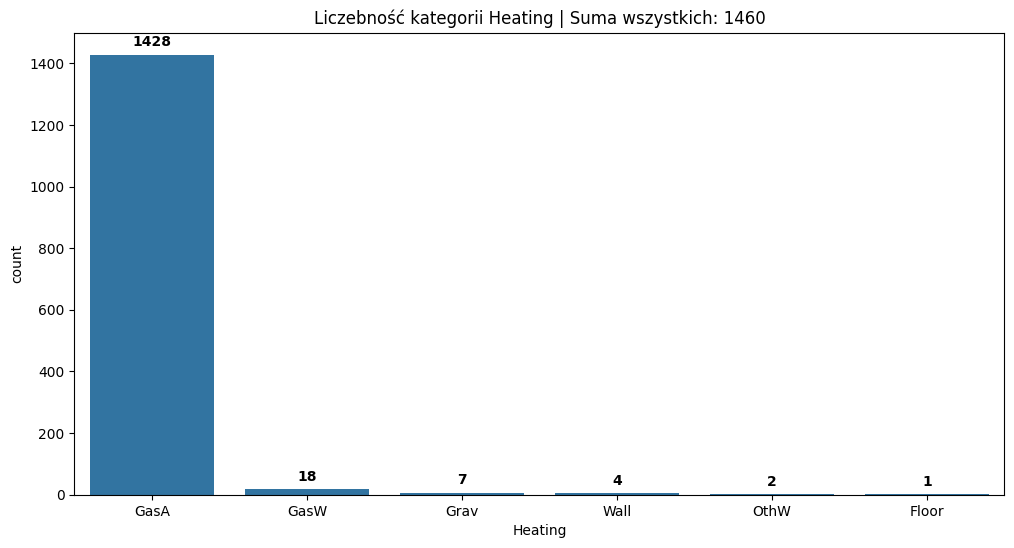

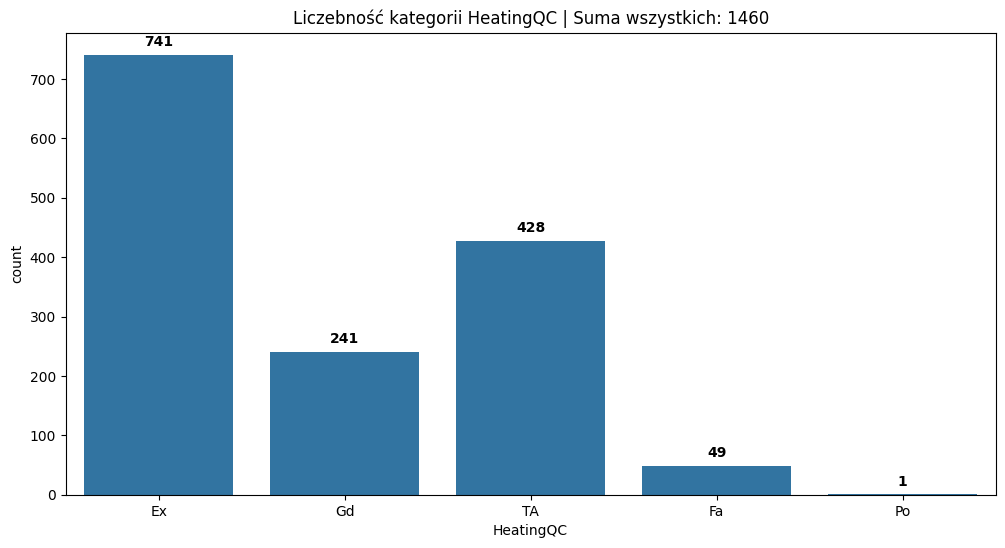

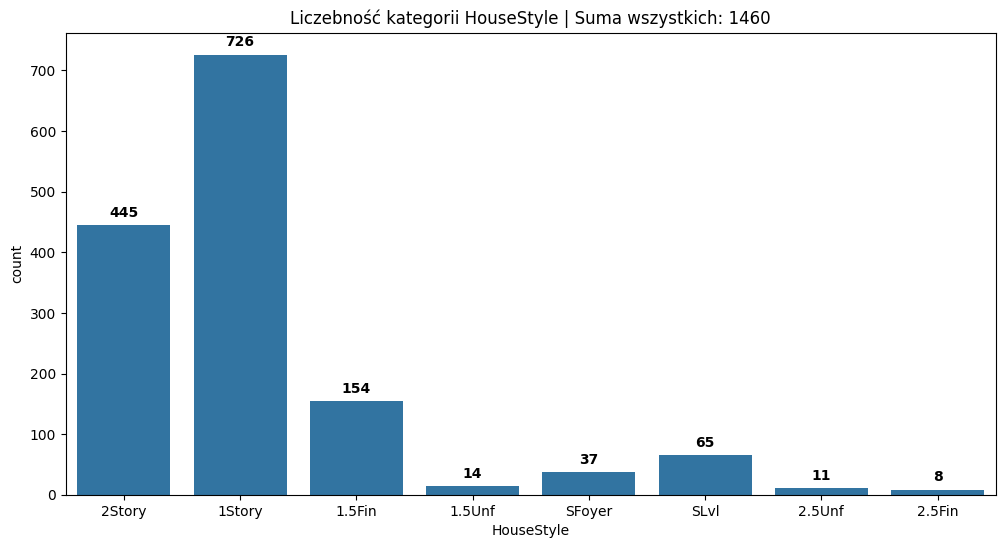

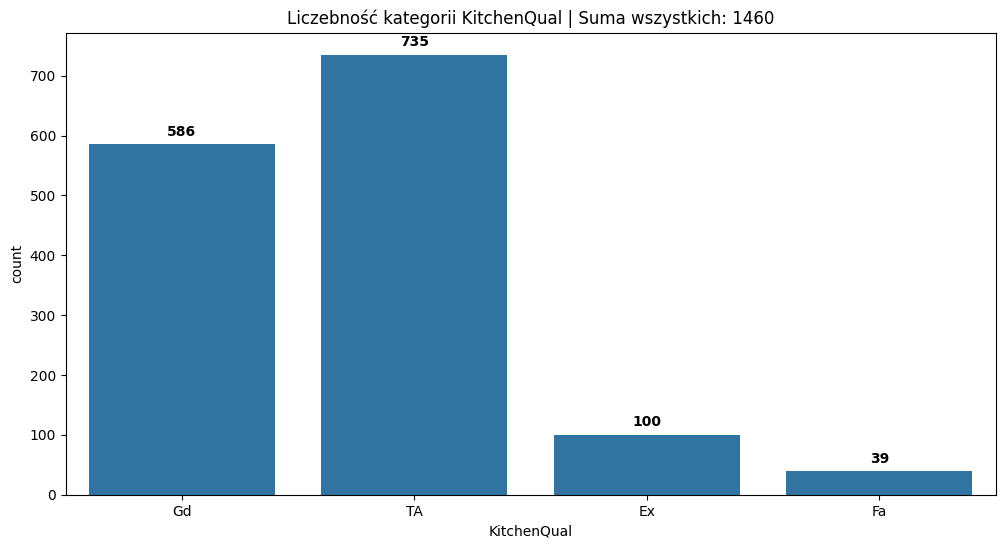

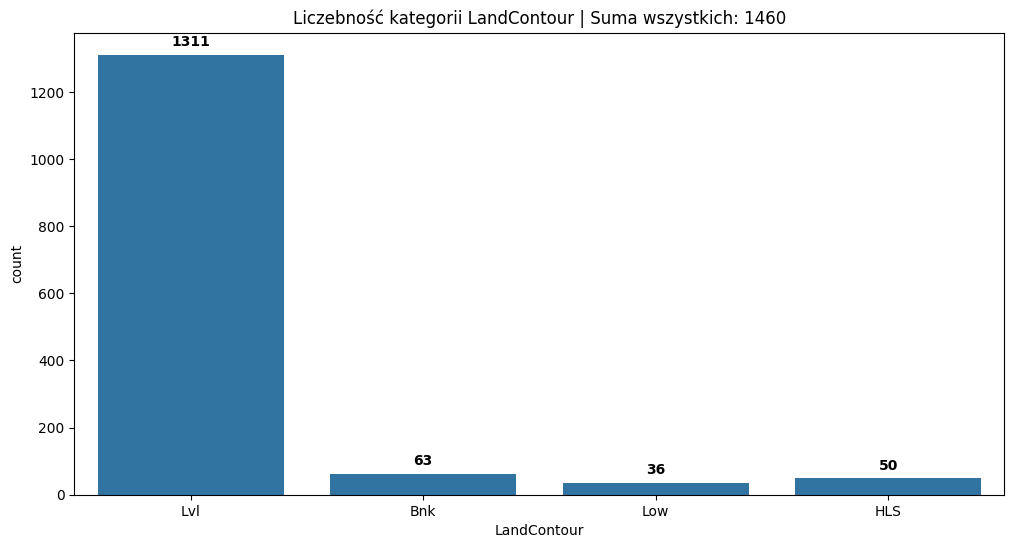

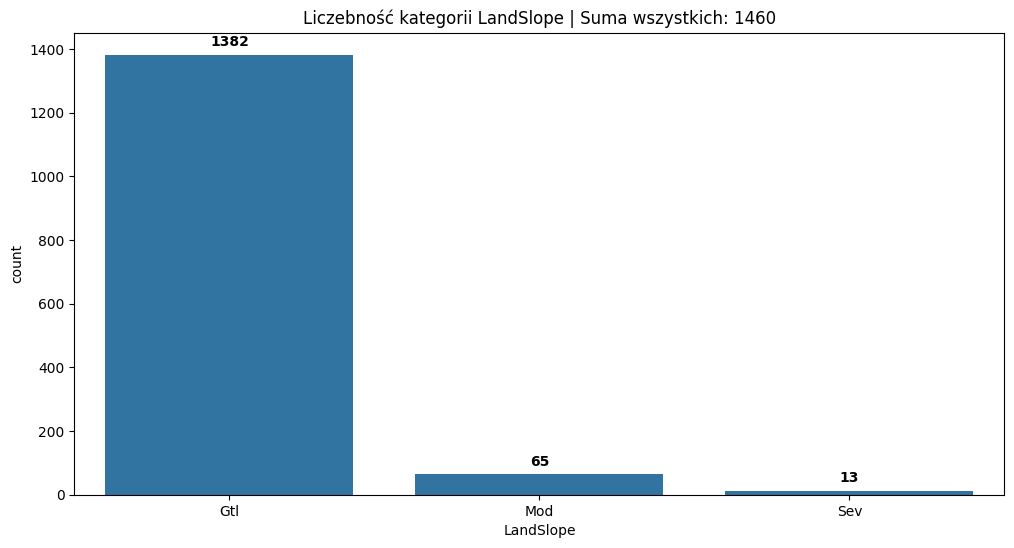

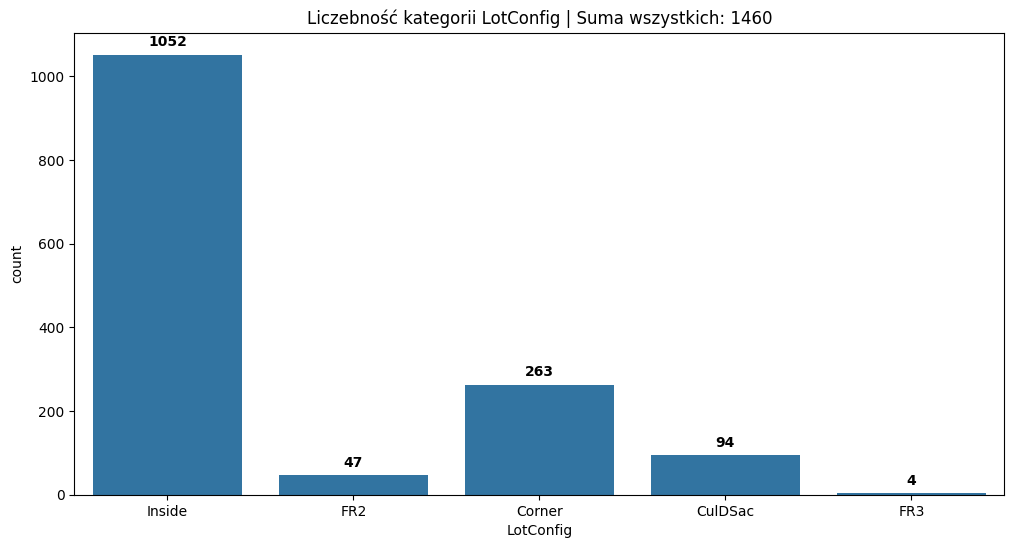

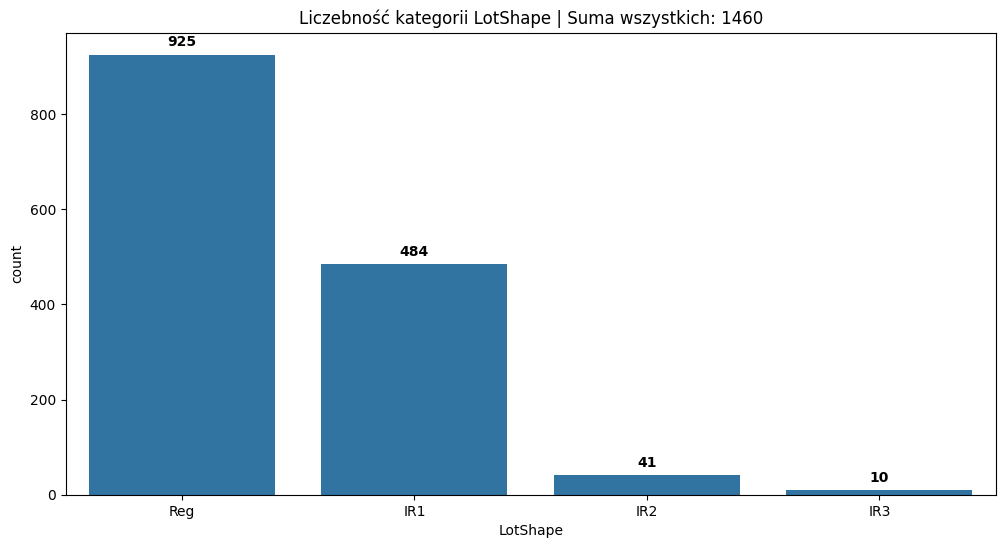

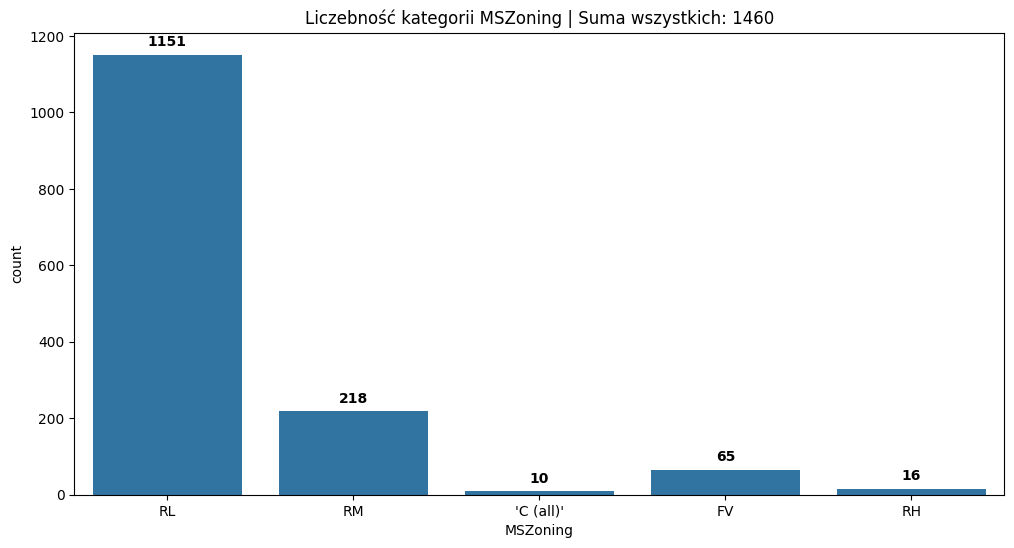

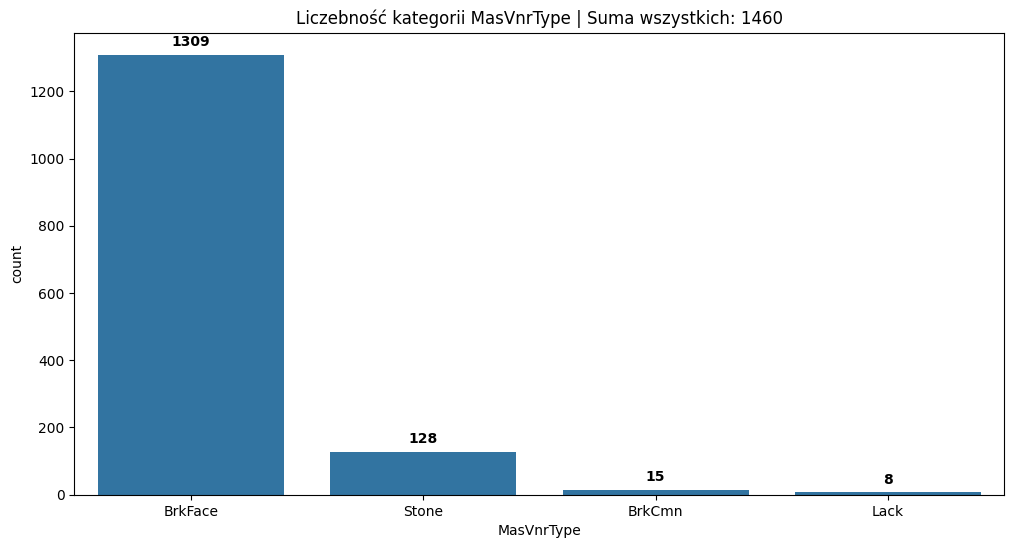

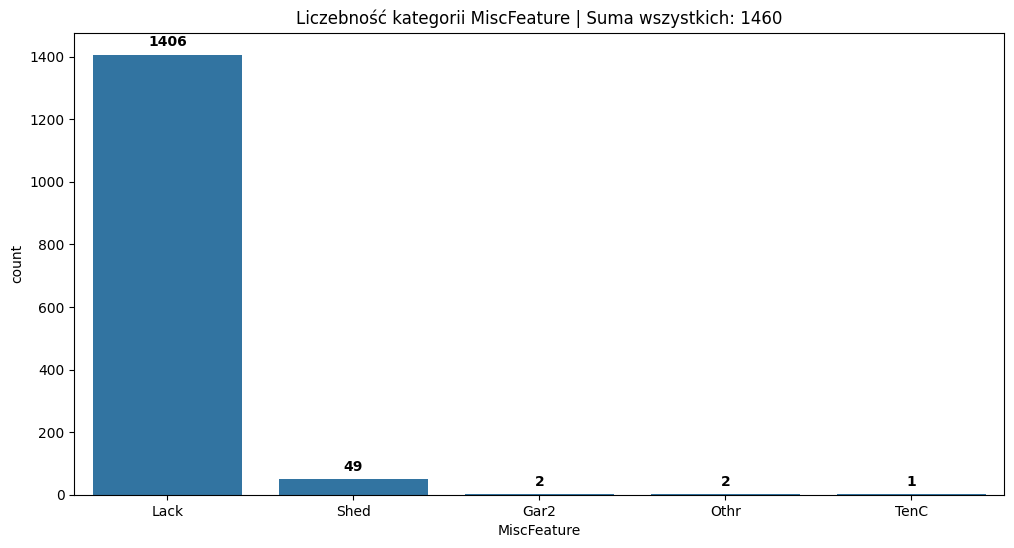

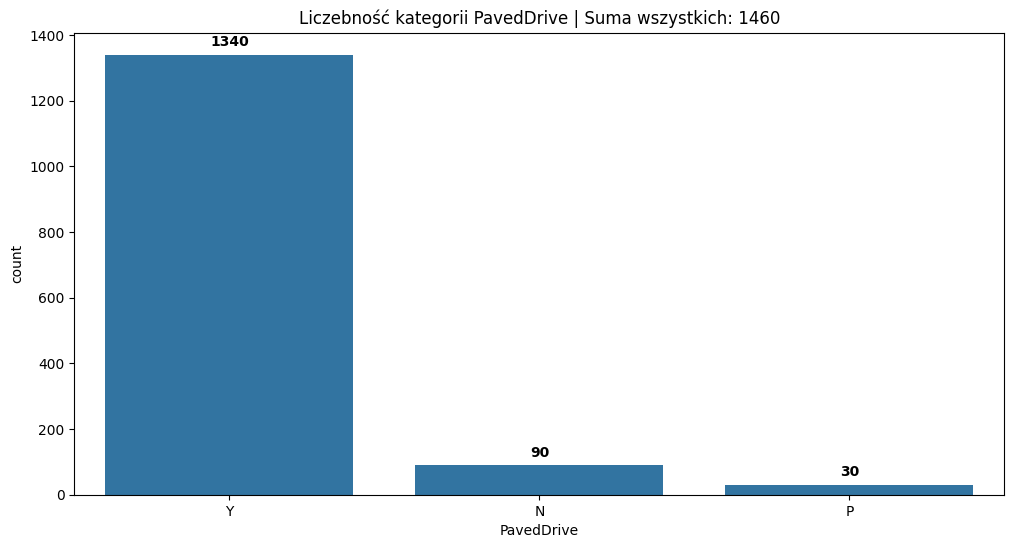

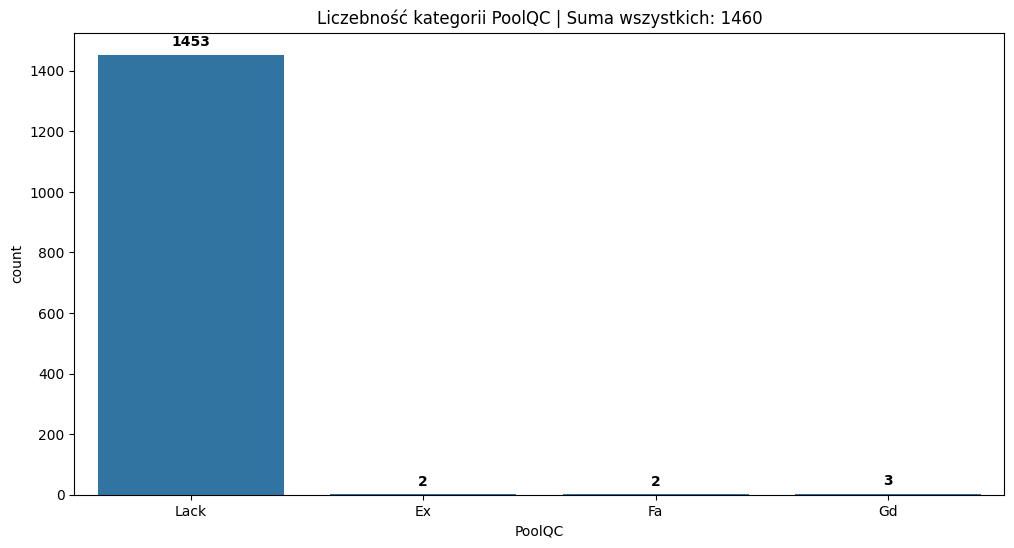

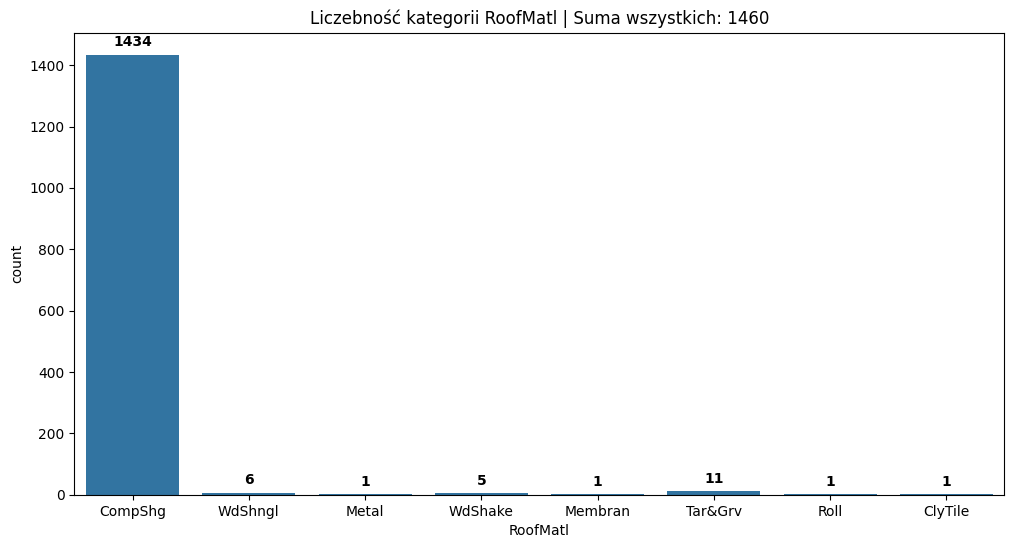

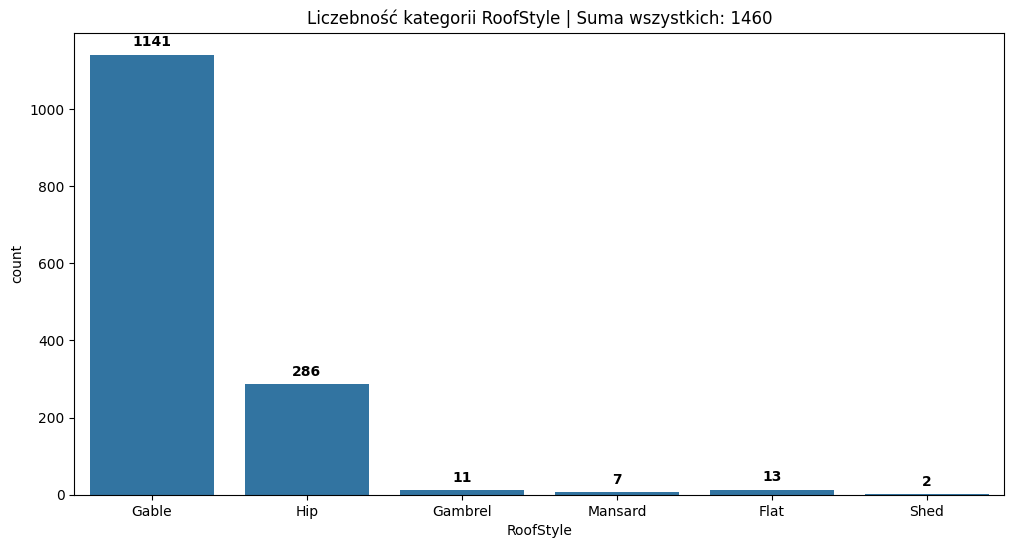

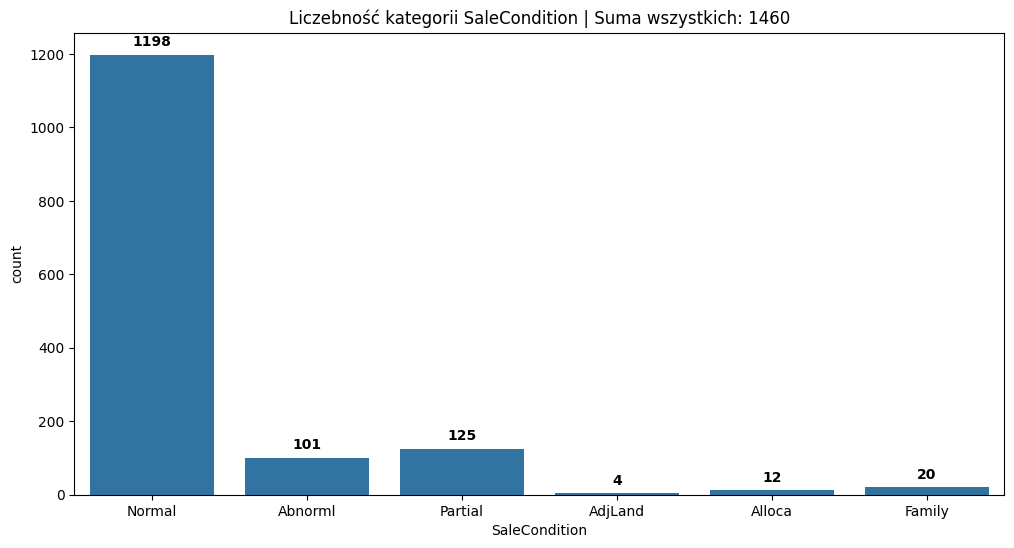

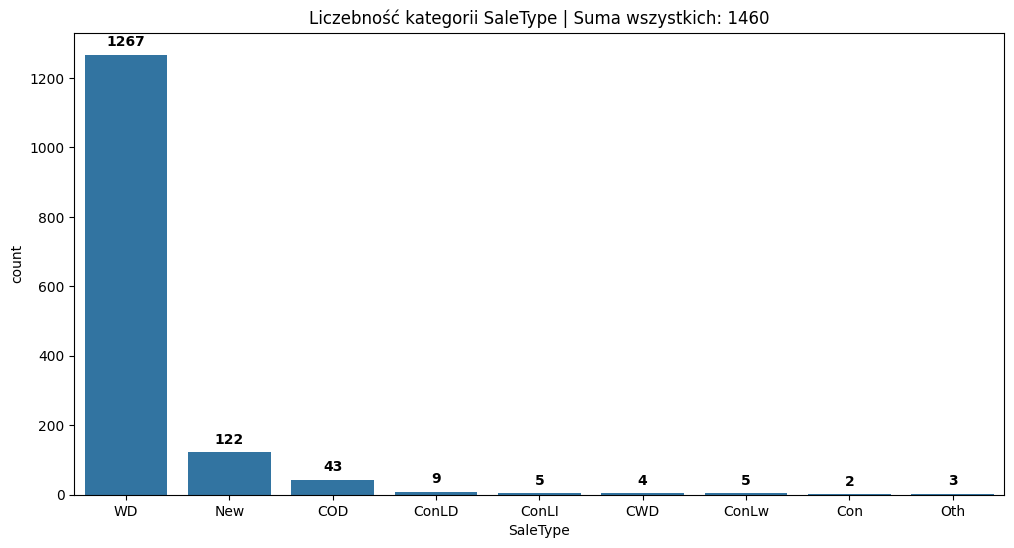

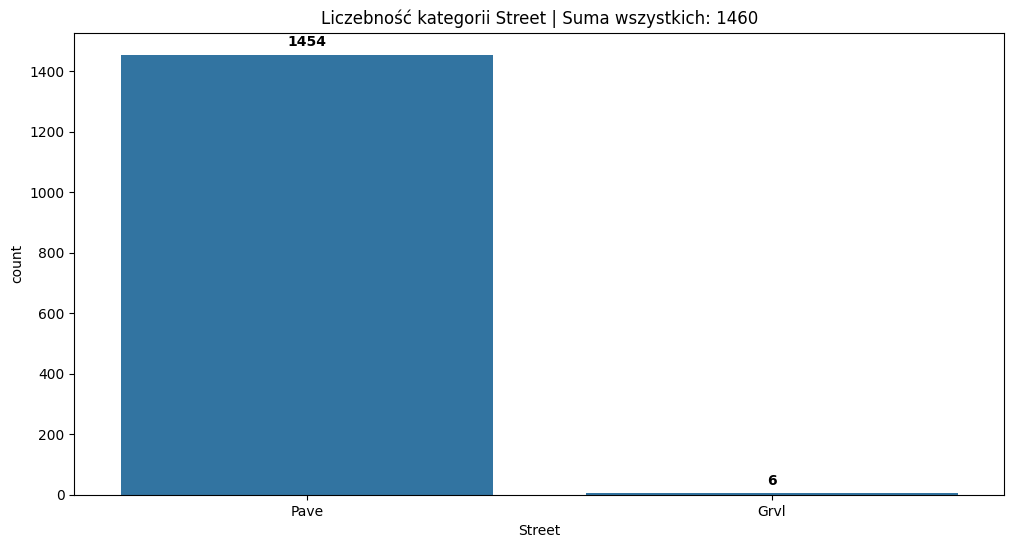

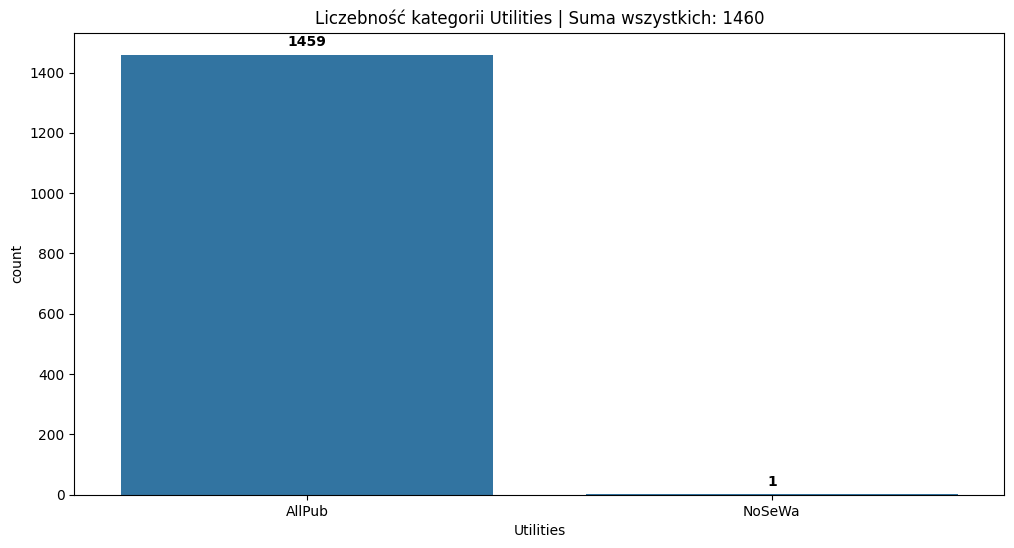

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

df_cat_s = df_cat_s.sort_index(axis=1)

for col in df_cat_s.columns:
    plt.figure(figsize=(12, 6))
    ax = sns.countplot(data=df_cat_s, x=col)
    
    # 1. Zliczenie sumy wszystkich słupków na danym wykresie
    total_count = sum(int(p.get_height()) for p in ax.patches)
    
    # Dodawanie liczb nad słupkami
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(format(height, '.0f'), 
                       (p.get_x() + p.get_width() / 2., height), 
                       ha='center', va='center', 
                       xytext=(0, 9), 
                       textcoords='offset points',
                       fontsize=10,
                       fontweight='bold')
    
    # 2. Wyświetlenie sumy w tytule za pomocą f-stringa
    plt.title(f"Liczebność kategorii {col} | Suma wszystkich: {total_count}")
    plt.show()